# Dificultad cognitiva subjetiva y factores de riesgo modificables de demencia

Proyecto de investigación de Machine Learning · Maestría en Ingeniería Biomédica, Universidad del Norte · Santiago Díaz, Gina Huguet y Leiry Mares · Septiembre de 2026

Notebook consolidado con las cuatro etapas del proyecto, base de datos, análisis exploratorio, auditoría de fuga de datos y preprocesamiento, y modelo base.

## Problema y pregunta de investigación

La dificultad cognitiva subjetiva (DCS), es decir la percepción de la propia persona de que tiene problemas para recordar o concentrarse, es una señal temprana asociada a cerca del doble de riesgo de demencia (Pike et al., Neuropsychol Rev, 2022). La importancia de identificar estas manifestaciones de manera temprana radica en que una proporción considerable de los casos de demencia está relacionada con factores de riesgo potencialmente modificables, la Comisión Lancet estima que alrededor del 45 % de los casos podrían atribuirse a estos factores.

Esto plantea la posibilidad de utilizar información sobre dichos factores para identificar, incluso antes de que exista un diagnóstico de demencia, a personas que presentan dificultades cognitivas subjetivas. A estos factores se suma el antecedente de accidente cerebrovascular (ACV), una condición neurológica y vascular asociada con un mayor riesgo de deterioro cognitivo. Por ello, este proyecto busca evaluar si la combinación de estos factores permite predecir la presencia de DCS en adultos, mediante un modelo de machine learning, utilizando información de 56.129 participantes de la National Health Interview Survey (NHIS) 2022–2023 de los CDC.

> Pregunta de investigación: ¿Cuál es el desempeño de un modelo de clasificación basado en factores de riesgo potencialmente modificables y antecedente de accidente cerebrovascular para predecir dificultad cognitiva subjetiva en adultos?

## Capítulo 1. Base de datos

### 1.1 Definición del problema

#### El problema

La demencia es una de las principales causas de discapacidad y dependencia en adultos mayores, y buena parte de sus casos es prevenible: la Comisión Lancet 2024 estimó que cerca del 45 % de los casos se asocia a 14 factores de riesgo modificables (Livingston et al., 2024). Para prevenir hace falta detectar a tiempo, y la dificultad cognitiva subjetiva, es decir la percepción de la propia persona de que tiene problemas para recordar o concentrarse, es una de las señales más tempranas: quienes la reportan tienen aproximadamente el doble de riesgo de desarrollar demencia (RR ≈ 2,07; Mitchell et al., 2014; RR ≈ 2,12; Wang et al., 2021). Sin embargo esta señal rara vez se evalúa de forma sistemática, mientras que la información sobre factores de riesgo (hipertensión, diabetes, depresión, audición, tabaquismo, escolaridad, antecedente de ACV) sí se registra de forma rutinaria. No se sabe con claridad cuánta información aporta ese perfil de factores de riesgo para anticipar la dificultad cognitiva, y ahí está el espacio que este proyecto busca explorar.

#### Pregunta de investigación

> ¿Cuál es el desempeño de un modelo de clasificación basado en factores de riesgo potencialmente modificables y antecedente de accidente cerebrovascular para predecir dificultad cognitiva subjetiva en adultos?

#### Objetivo general

Desarrollar y evaluar un modelo de clasificación que estime la probabilidad de presentar dificultad cognitiva subjetiva a partir de factores de riesgo potencialmente modificables asociados con demencia y del antecedente de accidente cerebrovascular, utilizando datos de la NHIS 2022–2023.

#### Objetivos específicos

1. Caracterizar la prevalencia de dificultad cognitiva subjetiva y la distribución de los factores predictores en la población estudiada.
2. Determinar la capacidad predictiva de los factores de riesgo potencialmente modificables y del antecedente de accidente cerebrovascular para identificar la presencia de dificultad cognitiva subjetiva.
3. Interpretar la contribución de los factores incluidos en el modelo a la predicción de dificultad cognitiva subjetiva, con especial énfasis en el antecedente de accidente cerebrovascular.

### 1.2 Justificación de la selección del dataset

- Pertinencia: la NHIS incluye la pregunta de cognición del Washington Group Short Set, un instrumento estandarizado internacionalmente, y la mayoría de los factores de riesgo de la Comisión Lancet 2024 medidos con las mismas preguntas en 2022 y 2023.
- Tamaño: más de 56.000 adultos, muy por encima del mínimo de 20.000 observaciones que pide la guía, y cada fila corresponde a una persona distinta.
- Datos reales y oficiales: encuesta nacional del National Center for Health Statistics (NCHS/CDC), con documentación pública completa, incluidos codebooks y descripción del diseño.
- Acceso libre e inmediato: los archivos de uso público se descargan sin registro.
- Dificultad adecuada: es un fenómeno multifactorial y autorreportado, así que no se espera un desempeño trivialmente alto, lo que deja margen para mejorar con modelos más complejos en las siguientes entregas.

### 1.3 Fuente de los datos y licencia

- La fuente es el National Center for Health Statistics, con la National Health Interview Survey (NHIS) de 2022 y 2023, en su módulo Sample Adult Interview, como archivos de uso público.
- Son datos de uso público, producidos por una agencia del gobierno federal de EE. UU., sin restricciones de derechos de autor. El NCHS pide citar la fuente y prohíbe cualquier intento de identificar a los participantes o de cruzar los datos con otras fuentes con ese fin.
- La documentación usada fueron los codebooks y los resúmenes de variables del Sample Adult File de 2022 y 2023.

### 1.4 Carga de los datos y criterios de inclusión

Los archivos se leen directamente desde los `.zip` descargados del CDC (carpeta `data/raw/`). Las recodificaciones, como los códigos de no respuesta 7, 8 y 9 que pasan a faltante, las etiquetas de categorías y la agrupación de los 10 niveles educativos en 5, vienen del codebook y no de los datos mismos, así que aplicarlas antes de la partición no mete fuga de información. El código está en `src/utils.py`.

Los criterios de inclusión fueron estos.

1. Adultos de 18 años o más, de los archivos 2022 y 2023.
2. Se excluyen las entrevistas respondidas por un informante o proxy, porque lo que interesa es la dificultad que percibe la propia persona.
3. Se excluyen los registros cuya variable objetivo quedó con código de no respuesta.

De los 57.173 adultos entrevistados en 2022 y 2023 quedan 56.129 en el dataset analítico, como resume la figura anterior. La exclusión más grande, 1.025 registros o un 1,8 %, corresponde a las entrevistas respondidas por un informante. Fue una decisión conceptual, porque la pregunta objetivo mide la dificultad percibida por la propia persona, y un familiar o cuidador responde desde otra perspectiva. El costo es un sesgo de selección conocido, ya que esas personas no pudieron responder por una condición física o mental y probablemente concentran los casos de deterioro más severo (se retoma en la sección 1.9.6). Solo 19 registros más se pierden por no respuesta en la variable objetivo.

In [1]:
import sys, warnings
from pathlib import Path
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

from src.utils import *

estilo_graficos()
np.random.seed(SEED)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

In [2]:
crudo = cargar_crudos()
print(f"Archivo crudo combinado: {crudo.shape[0]:,} filas x {crudo.shape[1]} columnas seleccionadas")
datos, flujo = construir_dataset(crudo)
flujo["excluidos"] = (-flujo["registros"].diff()).fillna(0).astype(int)
display(flujo)
print(f"Dataset analítico: {datos.shape[0]:,} adultos x {datos.shape[1]} columnas")

Archivo crudo combinado: 57,173 filas x 26 columnas seleccionadas


,paso,registros,excluidos
0,Adultos en los archivos 2022 + 2023,57173,0
1,Excluye entrevistas respondidas por un informa...,56148,1025
2,Excluye objetivo con código de no respuesta (7...,56129,19


Dataset analítico: 56,129 adultos x 25 columnas


```{figure} ../images/flujo_muestra.png
:name: fig-flujo-muestra
:width: 460px

Flujo de la muestra: de los adultos entrevistados en 2022-2023 al conjunto de entrenamiento y
prueba.
```

### 1.5 Diccionario de variables

La selección de predictoras sigue el marco de los 14 factores de riesgo potencialmente modificables de la Comisión Lancet 2024, más el antecedente de ACV, que es la exposición de interés de este proyecto, y tres variables sociodemográficas de ajuste (edad, sexo y raza o etnia). También se guardan algunas variables que **no** entran como predictoras, unas porque solo sirven para el EDA y otras porque hacen parte de la auditoría de fuga de datos de la sección 2.5.

In [3]:
display(DICCIONARIO.style.hide(axis="index").set_properties(**{"text-align": "left"}))

variable,variable_nhis,rol,tipo,unidad_categorias,significado,factor_lancet_2024
dificultad_cognitiva,COGMEMDFF_A,Objetivo,Binaria,"0 = ninguna; 1 = alguna, mucha o no puede",¿Tiene dificultad para recordar o concentrarse? (Washington Group),—
edad,AGEP_A,Predictora,Numérica discreta,Años (18-84; 85 = 85 o más),Edad del adulto entrevistado,No (confusor)
sexo,SEX_A,Predictora,Nominal binaria,Hombre / Mujer,Sexo del adulto,No (confusor)
raza_etnia,HISPALLP_A,Predictora,Nominal (7),Grupos raciales y origen hispano,Raza/etnia autodeclarada,No (confusor)
educacion,EDUCP_A,Predictora,Ordinal (5),Menos que secundaria … Posgrado,Máximo nivel educativo alcanzado (agrupado a partir de 10 niveles),Sí: baja escolaridad
hipertension,HYPEV_A,Predictora,Binaria,Sí / No,Alguna vez diagnosticado con hipertensión,Sí: hipertensión
colesterol_alto,CHLEV_A,Predictora,Binaria,Sí / No,Alguna vez diagnosticado con colesterol alto,Sí: colesterol LDL alto
diabetes,DIBEV_A,Predictora,Binaria,Sí / No,Alguna vez diagnosticado con diabetes,Sí: diabetes
acv,STREV_A,Predictora,Binaria,Sí / No,Alguna vez le dijeron que tuvo un ACV,No (exposición de interés)
depresion_dx,DEPEV_A,Predictora,Binaria,Sí / No,Alguna vez diagnosticado con depresión,Sí: depresión


#### Factores de la Comisión Lancet 2024 no disponibles en ambos años

De los 14 factores, la NHIS 2022-2023 permite medir 9 con preguntas idénticas en ambos años, que son escolaridad, hipertensión, colesterol, diabetes, depresión, pérdida auditiva, pérdida visual, tabaquismo y obesidad. El consumo de alcohol y la inactividad física solo se preguntaron en 2022, y el aislamiento social, el traumatismo craneoencefálico y la contaminación del aire no están disponibles con una medición comparable entre los dos años. Incluir los factores de un solo año obligaría a descartar la mitad de la muestra o a imputar un año completo, así que quedan declarados como limitación del proyecto.

### 1.6 Estructura de los datos

Los datos son transversales, cada fila es un adulto distinto, medido una sola vez, sin agregación, y no hay hogares repetidos dentro de un año. Los dos años son muestras independientes, no un seguimiento de las mismas personas. Esto tiene dos consecuencias para el modelado. La primera es que la validación no necesita agruparse por entidad, así que no hace falta usar `GroupKFold`. La segunda es que no aplican las rutas temporal ni espacial de la guía. El año se usa solo para estratificar la partición y para verificar que la variable objetivo no cambie entre 2022 y 2023 (sección 2.1).

In [4]:
estructura = pd.DataFrame({
    "característica": ["Unidad de observación", "Nivel de agregación", "Tipo de datos",
                       "Adultos por hogar", "Hogares repetidos dentro de un año",
                       "Componente temporal", "Componente espacial"],
    "valor": ["Un adulto seleccionado al azar en cada hogar", "Individual (sin agregación)",
              "Transversal: dos muestras anuales independientes (2022 y 2023)",
              "1 (por diseño de la encuesta)",
              int(datos.duplicated(["anio", "id_hogar"]).sum()),
              "Solo año y trimestre de entrevista (no es serie de tiempo)",
              "No hay coordenadas; solo región censal (no usada)"]})
display(estructura.style.hide(axis="index"))
print(datos.groupby("anio").size().rename("adultos").to_frame().T)

característica,valor
Unidad de observación,Un adulto seleccionado al azar en cada hogar
Nivel de agregación,Individual (sin agregación)
Tipo de datos,Transversal: dos muestras anuales independientes (2022 y 2023)
Adultos por hogar,1 (por diseño de la encuesta)
Hogares repetidos dentro de un año,0
Componente temporal,Solo año y trimestre de entrevista (no es serie de tiempo)
Componente espacial,No hay coordenadas; solo región censal (no usada)


anio      2022   2023
adultos  27153  28976


### 1.7 Reserva del conjunto de prueba

Siguiendo la guía, el conjunto de prueba se separó antes de tomar cualquier decisión basada en los datos, ya fuera de imputación, de agrupación de categorías, de umbrales o de selección de variables. La partición quedó en 80/20, estratificada por la variable objetivo y por el año, para conservar en ambos conjuntos la proporción de casos positivos y la mezcla de años. Como hay un solo adulto por hogar y los identificadores de hogar son aleatorios por año, no hay entidades repetidas que obliguen a usar `GroupKFold`. De aquí en adelante, todo el EDA se calcula únicamente con el conjunto de entrenamiento.

In [5]:
train, test = dividir(datos)
DIR_PROC.mkdir(parents=True, exist_ok=True)
train.to_csv(DIR_PROC / "train.csv", index=False)
test.to_csv(DIR_PROC / "test.csv", index=False)
datos.to_csv(DIR_PROC / "nhis_cognicion_2022_2023.csv", index=False)

resumen = pd.DataFrame({
    "conjunto": ["Entrenamiento", "Prueba", "Total"],
    "n": [len(train), len(test), len(datos)],
    "positivos": [train[OBJETIVO].sum(), test[OBJETIVO].sum(), datos[OBJETIVO].sum()],
    "prevalencia": [train[OBJETIVO].mean(), test[OBJETIVO].mean(), datos[OBJETIVO].mean()],
    "% de 2023": [(train.anio == 2023).mean(), (test.anio == 2023).mean(), (datos.anio == 2023).mean()]})
display(resumen.style.hide(axis="index").format({"n": "{:,}", "positivos": "{:,}",
                                                  "prevalencia": "{:.2%}", "% de 2023": "{:.2%}"}))

conjunto,n,positivos,prevalencia,% de 2023
Entrenamiento,"44,903","9,253",20.61%,51.62%
Prueba,"11,226","2,313",20.60%,51.62%
Total,"56,129","11,566",20.61%,51.62%


### 1.8 Tamaño de la muestra

La muestra supera con holgura el mínimo de 20.000 observaciones que pide la guía, con 56.129 en total y 44.903 para entrenar. Tras codificar las variables quedan 35 columnas, así que la relación entre observaciones y parámetros es de más de 1.000 por parámetro, y el riesgo de sobreajuste por dimensionalidad es bajo. La clase minoritaria, es decir quienes reportan DCS, tiene 11.566 casos en total y 9.253 en entrenamiento, un número suficiente para estimar métricas e intervalos de confianza estables. Como además hay un solo adulto por hogar, el número de entidades independientes coincide con el número de filas, así que el tamaño efectivo de la muestra no está inflado por mediciones repetidas.

In [6]:
n, p_vars = len(datos), len(PREDICTORAS)
pre_tmp = __import__("src.preprocesamiento", fromlist=["x"]).construir_preprocesador()
p_cols = pre_tmp.fit(train[PREDICTORAS]).transform(train[PREDICTORAS].head()).shape[1]
tam = pd.DataFrame({
    "indicador": ["Observaciones (total)", "Observaciones (entrenamiento)", "Predictoras (variables)",
                  "Columnas tras codificación one-hot y splines", "Relación n/p (entrenamiento / columnas)",
                  "Casos clase 1: con dificultad cognitiva", "Casos clase 0: sin dificultad cognitiva",
                  "Casos clase 1 en entrenamiento", "Entidades independientes (adultos = hogares)"],
    "valor": [f"{n:,}", f"{len(train):,}", p_vars, p_cols, f"{len(train) / p_cols:,.0f}",
              f"{datos[OBJETIVO].sum():,}", f"{(datos[OBJETIVO] == 0).sum():,}",
              f"{train[OBJETIVO].sum():,}", f"{len(datos):,} (un adulto por hogar)"]})
display(tam.style.hide(axis="index"))

indicador,valor
Observaciones (total),"56,129"
Observaciones (entrenamiento),"44,903"
Predictoras (variables),14
Columnas tras codificación one-hot y splines,35
Relación n/p (entrenamiento / columnas),"1,283"
Casos clase 1: con dificultad cognitiva,"11,566"
Casos clase 0: sin dificultad cognitiva,"44,563"
Casos clase 1 en entrenamiento,"9,253"
Entidades independientes (adultos = hogares),"56,129 (un adulto por hogar)"


### 1.9 Calidad de los datos (conjunto de entrenamiento)

#### 1.9.1 Magnitud y patrón de los valores faltantes

Los faltantes son escasos. Ninguna predictora supera el 3 % y solo el 6,2 % de las filas tiene al menos un dato ausente. Los más frecuentes son tabaquismo (3,0 %), frecuencia de depresión (2,3 %) y categoría de IMC (2,2 %). La matriz de nulos no muestra bloques de filas con muchos faltantes a la vez ni un patrón asociado a la edad, así que los huecos están dispersos y casi nunca coinciden en la misma persona. El IMC numérico tiene 8,5 % de faltantes, casi cuatro veces más que la categoría de IMC, y la explicación aparece en la sección siguiente. Es justamente la razón para usar la categoría, y no el valor numérico, como predictora.

In [7]:
import missingno as msno

cols_calidad = PREDICTORAS + ["imc"]
faltantes = (train[cols_calidad].isna().agg(["sum", "mean"]).T
             .rename(columns={"sum": "faltantes", "mean": "proporción"})
             .sort_values("proporción", ascending=False))
faltantes["faltantes"] = faltantes["faltantes"].astype(int)
display(faltantes.style.format({"proporción": "{:.2%}"}).bar(subset="proporción", color="#f4a582"))
print(f"Filas con al menos un faltante en las predictoras: {train[PREDICTORAS].isna().any(axis=1).mean():.2%}")

,faltantes,proporción
imc,3804,8.47%
tabaquismo,1341,2.99%
frecuencia_depresion,1013,2.26%
imc_categoria,996,2.22%
educacion,206,0.46%
colesterol_alto,123,0.27%
edad,106,0.24%
hipertension,70,0.16%
depresion_dx,66,0.15%
acv,54,0.12%


Filas con al menos un faltante en las predictoras: 6.18%


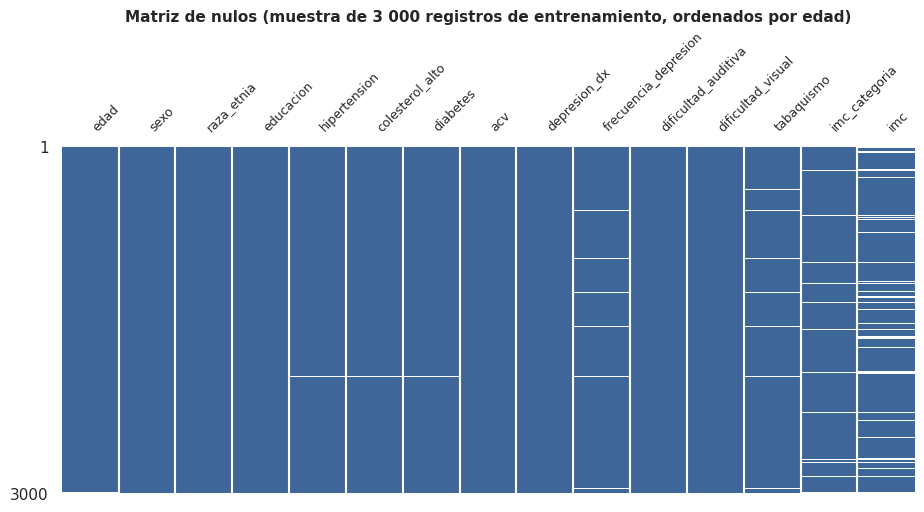

In [8]:
muestra = train[cols_calidad].sample(3000, random_state=SEED).sort_values("edad")
ax = msno.matrix(muestra, figsize=(11, 4.5), fontsize=9, sparkline=False, color=(0.25, 0.4, 0.6))
ax.set_title("Matriz de nulos (muestra de 3 000 registros de entrenamiento, ordenados por edad)", fontsize=11)
plt.show()

#### 1.9.2 Mecanismo de los faltantes (MCAR, MAR o MNAR)

La prueba de Little supone variables continuas con distribución normal multivariada, algo que no se cumple aquí porque casi todas las variables son categóricas. Por eso se usa la alternativa que permite la guía, que es comparar los registros completos con los incompletos y modelar la probabilidad de faltante en función de variables observadas. Si el faltante depende de variables observadas, el mecanismo no es MCAR.

Los registros incompletos tienen una prevalencia de DCS prácticamente igual a la de los completos (19,7 % frente a 20,7 %; p = 0,23; V de Cramér = 0,003) y una edad casi idéntica, con un efecto despreciable (correlación biserial = 0,01). Sin embargo el faltante sí depende de variables observadas, así que el mecanismo no es MCAR sino MAR.

- En frecuencia de depresión y en tabaquismo, las odds de tener el dato faltante son cerca de un 30 % mayores en 2023 (OR ≈ 1,3), algo que coincide con el aumento de respuestas de tipo no determinado que registra el codebook de ese año. Parece más un efecto del trabajo de campo que de las personas encuestadas.
- En categoría de IMC, las mujeres tienen odds 4,4 veces mayores de no tener el dato de peso o talla, y quienes tienen DCS las tienen algo menores (OR = 0,71). La no respuesta al peso por deseabilidad social está documentada en encuestas de salud, así que tampoco se puede descartar un componente MNAR.

Para el preprocesamiento, como los faltantes son pocos y de tipo MAR, una imputación simple dentro del pipeline es razonable, pero conviene añadir un indicador de faltante para las tres variables con más del 2 %, de modo que el modelo pueda aprovechar el hecho de que el dato falte.

In [9]:
from scipy import stats

incompleto = train[PREDICTORAS].isna().any(axis=1)
comp = pd.DataFrame({
    "completos": [train.loc[~incompleto, OBJETIVO].mean(), train.loc[~incompleto, "edad"].median(),
                  (train.loc[~incompleto, "edad"] >= 65).mean(), (train.loc[~incompleto, "sexo"] == "Mujer").mean()],
    "incompletos": [train.loc[incompleto, OBJETIVO].mean(), train.loc[incompleto, "edad"].median(),
                    (train.loc[incompleto, "edad"] >= 65).mean(), (train.loc[incompleto, "sexo"] == "Mujer").mean()]},
    index=["Prevalencia de dificultad cognitiva", "Edad mediana", "Proporción de 65+ años", "Proporción de mujeres"])

tab = pd.crosstab(incompleto, train[OBJETIVO])
chi2, p_chi, _, _ = stats.chi2_contingency(tab)
u = stats.mannwhitneyu(train.loc[incompleto, "edad"].dropna(), train.loc[~incompleto, "edad"].dropna())
r_rb = 1 - 2 * u.statistic / (incompleto.sum() * (~incompleto).sum())
display(comp)
print(f"Objetivo vs. incompleto: chi2 = {chi2:.1f}, p = {p_chi:.2e}, V de Cramér = {cramers_v(tab):.3f}")
print(f"Edad vs. incompleto: Mann-Whitney p = {u.pvalue:.2e}, correlación biserial por rangos = {r_rb:.3f}")

,completos,incompletos
Prevalencia de dificultad cognitiva,0.2067,0.1969
Edad mediana,54.0000,55.0000
Proporción de 65+ años,0.3186,0.3080
Proporción de mujeres,0.5396,0.6304


Objetivo vs. incompleto: chi2 = 1.5, p = 2.27e-01, V de Cramér = 0.003
Edad vs. incompleto: Mann-Whitney p = 2.20e-02, correlación biserial por rangos = 0.013


In [10]:
import statsmodels.formula.api as smf

tmp = train.assign(edad10=train["edad"] / 10, mujer=(train["sexo"] == "Mujer").astype(int),
                   f_dep=train["frecuencia_depresion"].isna().astype(int),
                   f_tab=train["tabaquismo"].isna().astype(int),
                   f_imc=train["imc_categoria"].isna().astype(int)).dropna(subset=["edad"])
filas = []
for var, nombre in [("f_dep", "frecuencia_depresion"), ("f_tab", "tabaquismo"), ("f_imc", "imc_categoria")]:
    m = smf.logit(f"{var} ~ edad10 + mujer + dificultad_cognitiva + C(anio)", data=tmp).fit(disp=0)
    ic = np.exp(m.conf_int())
    for term, etiqueta in [("edad10", "edad (por 10 años)"), ("mujer", "mujer"),
                           ("dificultad_cognitiva", "dificultad cognitiva"), ("C(anio)[T.2023]", "año 2023")]:
        filas.append([nombre, etiqueta, np.exp(m.params[term]), ic.loc[term, 0], ic.loc[term, 1], m.pvalues[term]])
mec = pd.DataFrame(filas, columns=["variable con faltante", "predictor del faltante", "OR", "IC95% inf",
                                   "IC95% sup", "p"])
display(mec.style.hide(axis="index").format({"OR": "{:.2f}", "IC95% inf": "{:.2f}", "IC95% sup": "{:.2f}",
                                             "p": "{:.1e}"}))

variable con faltante,predictor del faltante,OR,IC95% inf,IC95% sup,p
frecuencia_depresion,edad (por 10 años),1.01,0.98,1.05,5.5e-01
frecuencia_depresion,mujer,1.07,0.94,1.22,2.8e-01
frecuencia_depresion,dificultad cognitiva,0.87,0.74,1.02,9.6e-02
frecuencia_depresion,año 2023,1.33,1.17,1.51,9.3e-06
tabaquismo,edad (por 10 años),0.99,0.96,1.02,3.8e-01
tabaquismo,mujer,1.01,0.91,1.13,8.6e-01
tabaquismo,dificultad cognitiva,0.94,0.82,1.08,3.7e-01
tabaquismo,año 2023,1.31,1.17,1.46,1.7e-06
imc_categoria,edad (por 10 años),1.04,1.00,1.07,4.6e-02
imc_categoria,mujer,4.39,3.70,5.21,5.9e-64


##### Un caso de faltante no aleatorio, peso y talla suprimidos

Para proteger la confidencialidad, el NCHS reemplaza por el código 996/96 el peso o la talla cuando el valor es excepcionalmente bajo o alto. Es decir, el dato falta por su propio valor, que es justamente la definición de MNAR. Por fortuna la variable `imc_categoria` (BMICAT_A) se había calculado antes de la supresión, así que permite comprobarlo.

Esta es la evidencia del mecanismo MNAR. Entre las personas con peso o talla suprimidos, el 57,9 % tiene obesidad y el 9,5 % bajo peso, frente a 31,5 % y 1,0 % entre quienes sí tienen el dato publicado. Si se usara el IMC numérico y esos valores se imputaran con la mediana, se estarían borrando justo los casos extremos. La variable `imc_categoria` conserva esa información, con solo 2,2 % de faltantes frente al 8,5 % del IMC numérico, así que se usa la categoría como predictora y el IMC numérico queda reservado para el EDA.

In [11]:
tabla_mnar = (pd.crosstab(train["peso_talla_suprimidos"].map({0: "Peso y talla publicados", 1: "Peso o talla suprimidos"}),
                          train["imc_categoria"], normalize="index")[ORDENES["imc_categoria"]])
display(tabla_mnar.style.format("{:.1%}").background_gradient(axis=1, cmap="Oranges"))
print(f"IMC numérico faltante: {train['imc'].isna().mean():.2%} | IMC categórico faltante: {train['imc_categoria'].isna().mean():.2%}")

imc_categoria,Bajo peso,Normal,Sobrepeso,Obesidad
peso_talla_suprimidos,,,,
Peso o talla suprimidos,9.5%,19.2%,13.4%,57.9%
Peso y talla publicados,1.0%,31.6%,35.9%,31.5%


IMC numérico faltante: 8.47% | IMC categórico faltante: 2.22%


##### Faltante estructural, por diseño del cuestionario

La pregunta de seguimiento `frecuencia_dificultad_cog` solo se le hace a quien respondió que sí tiene dificultad cognitiva.

Todos los adultos sin DCS aparecen como no aplica, porque la pregunta de seguimiento solo se hace cuando la respuesta al objetivo fue positiva (los 1.306 positivos que quedan como no aplica reportaron dificultad para concentrarse pero no para recordar). Es un faltante estructural, determinado por el propio objetivo, ya que la variable conoce la respuesta de antemano. Por eso constituye fuga de datos y se excluye del modelo (se verifica de forma cuantitativa en la sección 2.5).

In [12]:
display(pd.crosstab(train["frecuencia_dificultad_cog"] == "No aplica", train[OBJETIVO],
                    rownames=["¿'No aplica'?"], colnames=["dificultad_cognitiva"]))

dificultad_cognitiva,0,1
¿'No aplica'?,,
False,0,7947
True,35650,1306


#### 1.9.3 Duplicados exactos y casi-duplicados

No hay duplicados exactos. Ningún hogar se repite dentro de un año y ninguna fila es idéntica en todas sus columnas. Sí hay casi-duplicados en el sentido de perfiles repetidos, ya que el 16,3 % de las filas comparte exactamente su combinación de predictoras con otra persona. Esto es esperable y no es un error, porque son 13 variables categóricas con pocos niveles más la edad, así que dos personas distintas pueden coincidir en todo (el perfil más repetido aparece 16 veces). Además, 879 de esos perfiles tienen personas en ambas clases, y eso anticipa un límite al desempeño alcanzable, porque con estas variables algunas personas son indistinguibles aunque una reporte DCS y la otra no. Por eso no se eliminan, ya que hacerlo borraría personas reales y distorsionaría la prevalencia.

In [13]:
dup_id = datos.duplicated(["anio", "id_hogar"]).sum()
dup_fila = train.drop(columns=["id_hogar"]).duplicated().sum()
dup_pred = train.duplicated(PREDICTORAS).sum()
perfiles = train.groupby(PREDICTORAS, dropna=False).size()
print(f"Hogares repetidos dentro de un mismo año: {dup_id}")
print(f"Filas idénticas en todas las columnas (sin el id): {dup_fila}")
print(f"Filas con el mismo perfil de predictoras: {dup_pred:,} ({dup_pred / len(train):.2%})")
print(f"Perfiles distintos: {len(perfiles):,}; perfil más frecuente repetido {perfiles.max()} veces")
conflicto = train.groupby(PREDICTORAS, dropna=False)[OBJETIVO].agg(["size", "mean"])
conflicto = conflicto[(conflicto["size"] > 1) & conflicto["mean"].between(0.01, 0.99)]
print(f"Perfiles repetidos con etiquetas distintas (ambas clases): {len(conflicto):,}")

Hogares repetidos dentro de un mismo año: 0
Filas idénticas en todas las columnas (sin el id): 0
Filas con el mismo perfil de predictoras: 7,304 (16.27%)
Perfiles distintos: 37,599; perfil más frecuente repetido 16 veces
Perfiles repetidos con etiquetas distintas (ambas clases): 879


#### 1.9.4 Outliers

La edad no tiene outliers según el criterio IQR. Su única particularidad es el truncamiento en 85 años (3,4 % de los adultos), que impone el NCHS para proteger la confidencialidad. El valor 85 significa en realidad 85 años o más, así que la variable subestima la edad de los adultos más longevos. El IMC calculado tiene 1,55 % de outliers por encima de 42,2 kg/m², que corresponden a obesidad severa y son valores fisiológicamente plausibles, no errores de registro. La decisión es no eliminarlos ni recortarlos. La edad se modela con splines, lo que atenúa la influencia de los extremos, y el IMC numérico de todas formas no entra al modelo.

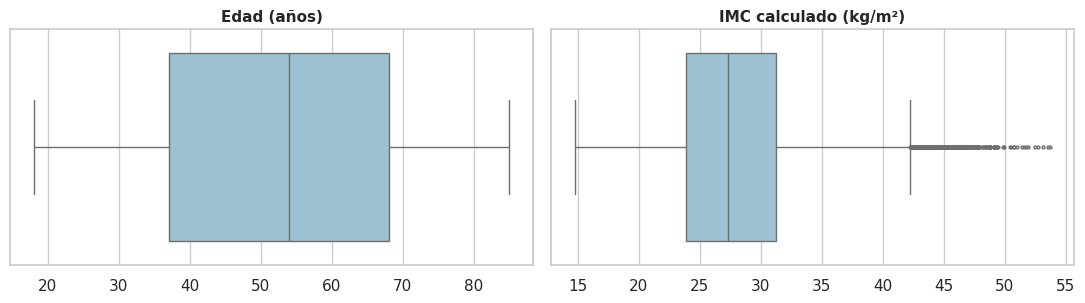

variable,mín,Q1,Q3,máx,límite inf,límite sup,outliers IQR,proporción
edad,18.0,37.0,68.0,85.0,-9.5,114.5,0,0.00%
imc,14.8,23.9,31.2,53.7,12.9,42.2,636,1.55%


Adultos con edad truncada en 85 (85 o más): 1,525 (3.40%)


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
for ax, var, titulo in [(axes[0], "edad", "Edad (años)"), (axes[1], "imc", "IMC calculado (kg/m²)")]:
    sns.boxplot(x=train[var], ax=ax, color="#92c5de", fliersize=2)
    ax.set_title(titulo); ax.set_xlabel("")
plt.tight_layout(); plt.show()

filas = []
for var in ["edad", "imc"]:
    x = train[var].dropna()
    q1, q3 = x.quantile([0.25, 0.75]); iqr = q3 - q1
    li, ls = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    filas.append([var, x.min(), q1, q3, x.max(), li, ls, ((x < li) | (x > ls)).sum(), ((x < li) | (x > ls)).mean()])
display(pd.DataFrame(filas, columns=["variable", "mín", "Q1", "Q3", "máx", "límite inf", "límite sup",
                                      "outliers IQR", "proporción"]).style.hide(axis="index")
        .format({"proporción": "{:.2%}", "mín": "{:.1f}", "Q1": "{:.1f}", "Q3": "{:.1f}", "máx": "{:.1f}",
                 "límite inf": "{:.1f}", "límite sup": "{:.1f}"}))
print(f"Adultos con edad truncada en 85 (85 o más): {(train['edad'] == 85).sum():,} ({(train['edad'] == 85).mean():.2%})")

#### 1.9.5 Valores imposibles o inconsistentes

No se encontraron valores imposibles. Todas las edades están entre 18 y 85 años, todos los IMC en rangos fisiológicos y todas las categorías corresponden a las del codebook. La categoría de IMC calculada con peso y talla coincide con la oficial de la NHIS en el 99,8 % de los casos, y los 73 desacuerdos están todos en la frontera entre categorías contiguas, algo compatible con el redondeo de peso y talla a libras y pulgadas enteras. El 1,6 % de los adultos con diagnóstico de depresión dice que nunca se siente deprimido, y esto no es una inconsistencia sino lo esperable en personas en remisión o en tratamiento. Muestra, además, que las dos variables de depresión capturan cosas distintas, el diagnóstico histórico y los síntomas actuales.

In [15]:
# 1) Rangos y categorías válidas
print("Edad fuera de 18-85:", ((train["edad"] < 18) | (train["edad"] > 85)).sum())
print("IMC fuera de 12-70 kg/m²:", ((train["imc"] < 12) | (train["imc"] > 70)).sum())
invalidas = {v: sorted(set(train[v].dropna()) - set(CATEGORIAS.get(v) or ORDENES.get(v)))
             for v in PREDICTORAS_CAT}
print("Categorías fuera del codebook:", {k: v for k, v in invalidas.items() if v} or "ninguna")

# 2) Consistencia entre el IMC calculado y la categoría oficial de la NHIS
cat_calc = pd.cut(train["imc"], [0, 18.5, 25, 30, 100], right=False, labels=ORDENES["imc_categoria"])
ambos = train["imc_categoria"].notna() & cat_calc.notna()
acuerdo = (cat_calc[ambos].astype(str) == train.loc[ambos, "imc_categoria"]).mean()
print(f"Acuerdo entre la categoría de IMC calculada y BMICAT_A: {acuerdo:.2%} de {ambos.sum():,} registros")
display(pd.crosstab(train.loc[ambos, "imc_categoria"], cat_calc[ambos], rownames=["BMICAT_A (NHIS)"],
                    colnames=["categoría calculada"]))

# 3) Coherencia lógica: 'nunca se siente deprimido' con diagnóstico de depresión
print("Diagnóstico de depresión pero 'nunca' se siente deprimido:",
      f"{((train['depresion_dx'] == 'Sí') & (train['frecuencia_depresion'] == 'Nunca')).mean():.2%}")

Edad fuera de 18-85: 0
IMC fuera de 12-70 kg/m²: 0
Categorías fuera del codebook: ninguna
Acuerdo entre la categoría de IMC calculada y BMICAT_A: 99.82% de 41,099 registros


categoría calculada,Bajo peso,Normal,Sobrepeso,Obesidad
BMICAT_A (NHIS),,,,
Bajo peso,402,2,0,0
Normal,0,12958,32,0
Obesidad,0,0,28,12934
Sobrepeso,0,11,14732,0


Diagnóstico de depresión pero 'nunca' se siente deprimido: 1.56%


#### 1.9.6 Sesgos de muestreo y representatividad

La NHIS usa un diseño muestral complejo, donde cada adulto tiene un peso muestral que indica a cuántas personas de la población representa. Comparar las proporciones sin ponderar, que es lo que ve el modelo, con las ponderadas, que es lo que ocurre en la población real, muestra hacia dónde está sesgada la muestra.

La muestra sin ponderar sobrerrepresenta a los adultos de 65 años o más (31,8 % en la muestra frente a 21,8 % en la población, unos 10 puntos de diferencia), a las personas con educación universitaria (+5,1 pp) y a los blancos no hispanos (+4,0 pp), y subrepresenta a los hispanos (-2,8 pp). Como la DCS aumenta con la edad, su prevalencia en la muestra (20,6 %) resulta algo mayor que en la población (19,4 %). Hay otros sesgos de representatividad que vale la pena declarar.

- Cobertura. La NHIS excluye a la población institucionalizada, como hogares de cuidado prolongado y prisiones, que es justo donde se concentran las personas con demencia avanzada.
- No respuesta. La tasa de respuesta de adultos fue del 47,0 % en 2023 (NCHS), y quienes no responden pueden diferir en salud de quienes sí lo hacen.
- Exclusión de proxies. Se excluyó a quienes no podían responder por sí mismos.
- Autorreporte. Los diagnósticos y las dificultades dependen de la percepción y del acceso previo a servicios de salud.

El modelo se entrena sin pesos muestrales, porque busca discriminar entre personas y no estimar prevalencias poblacionales. Aun así, sus probabilidades reflejan la composición de la muestra y no la de la población de EE. UU., y eso queda declarado como limitación.

In [16]:
def prop(df, cond, w=None):
    return np.average(cond, weights=w)

ind = {
    "Dificultad cognitiva": train[OBJETIVO] == 1,
    "65 años o más": train["edad"] >= 65,
    "Mujer": train["sexo"] == "Mujer",
    "Blanco no hispano": train["raza_etnia"] == "Blanco no hispano",
    "Hispano": train["raza_etnia"] == "Hispano",
    "Pregrado o posgrado": train["educacion"].isin(["Pregrado", "Posgrado"]),
    "Antecedente de ACV": train["acv"] == "Sí"}
sesgo = pd.DataFrame({"sin ponderar (muestra)": {k: prop(train, v) for k, v in ind.items()},
                      "ponderada (población EE. UU.)": {k: prop(train, v, train["peso_muestral"]) for k, v in ind.items()}})
sesgo["diferencia (pp)"] = 100 * (sesgo.iloc[:, 0] - sesgo.iloc[:, 1])
display(sesgo.style.format({"sin ponderar (muestra)": "{:.2%}", "ponderada (población EE. UU.)": "{:.2%}",
                            "diferencia (pp)": "{:+.1f}"}))

,sin ponderar (muestra),ponderada (población EE. UU.),diferencia (pp)
Dificultad cognitiva,20.61%,19.44%,+1.2
65 años o más,31.79%,21.77%,+10.0
Mujer,54.52%,51.49%,+3.0
Blanco no hispano,66.08%,62.12%,+4.0
Hispano,14.51%,17.28%,-2.8
Pregrado o posgrado,38.25%,33.18%,+5.1
Antecedente de ACV,3.47%,2.63%,+0.8


### 1.10 Consideraciones éticas

- Datos personales y anonimización. Los archivos de uso público no contienen nombres, direcciones ni fechas exactas. El identificador de hogar es aleatorio y no se puede vincular entre años, y la geografía se limita a la región censal.
- Riesgo de reidentificación. El NCHS lo mitiga truncando la edad en 85 años, suprimiendo pesos y tallas extremos y agrupando categorías raras. El proyecto no añade coordenadas ni marcas de tiempo precisas, solo año y trimestre, y respeta la prohibición de intentar identificar a los participantes.
- Variables sensibles. Raza y etnia se usan como variable de ajuste porque la literatura documenta diferencias en la exposición a factores de riesgo, pero su uso en un modelo predictivo puede perpetuar inequidades. En el modelo base sus coeficientes se reportan con cautela, y en entregas posteriores conviene evaluar el desempeño por subgrupo.
- Uso responsable del modelo. La variable objetivo es autorreportada y los datos son de EE. UU., así que el modelo no es una herramienta diagnóstica ni debería aplicarse en otra población sin una validación local previa.
- Salud mental. El dataset incluye información sobre depresión, que se trata de forma agregada y sin intentar inferencias a nivel individual.

## Capitulo 2. Analisis exploratorio de datos (EDA)

Todo el análisis de este capítulo usa únicamente el conjunto de entrenamiento (44.903 adultos), reservado en la sección 1.7. El conjunto de prueba no se abre hasta la evaluación final del modelo base.

Dado el tamaño de la muestra, casi cualquier diferencia resulta estadísticamente significativa, así que cada prueba se acompaña de un tamaño de efecto y, cuando se hacen muchas pruebas a la vez, los valores p se corrigen por comparaciones múltiples con el método de Holm.

In [1]:
import sys, warnings
from pathlib import Path
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

from src.utils import *

estilo_graficos()
np.random.seed(SEED)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

from scipy import stats
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.proportion import proportion_confint

train, _ = cargar_particiones()
y = train[OBJETIVO]
print(f"Conjunto de entrenamiento: {train.shape[0]:,} filas")

def dummies_referencia(df):
    # One-hot con la misma categoría de referencia que usará el modelo
    out = df.copy()
    for v in PREDICTORAS_CAT:
        orden = CATEGORIAS.get(v) or ORDENES.get(v)
        if v == "imc_categoria":
            orden = ["Normal", "Bajo peso", "Sobrepeso", "Obesidad"]
        out[v] = pd.Categorical(out[v], categories=orden)
    return pd.get_dummies(out[PREDICTORAS_CAT], drop_first=True, dtype=float)

def prev_ic(serie_y):
    k, n = serie_y.sum(), serie_y.count()
    li, ls = proportion_confint(k, n, method="wilson")
    return pd.Series({"n": n, "prevalencia": k / n, "ic_inf": li, "ic_sup": ls})

Conjunto de entrenamiento: 44,903 filas


### 2.1 Análisis de la variable objetivo

La pregunta original tiene cuatro niveles. Se dicotomiza en 0 para sin dificultad y 1 para alguna dificultad, mucha dificultad o no puede, porque los niveles superiores son demasiado escasos para modelarlos por separado y porque la literatura sobre queja cognitiva subjetiva considera relevante cualquier nivel de dificultad percibida.

En entrenamiento, el 20,6 % de los adultos reporta algún grado de DCS, unos 9.253 casos. Casi todos esos casos corresponden al nivel de alguna dificultad (18,3 %), mucha dificultad es el 2,2 % y no puede es apenas el 0,03 %, solo 15 personas, lo que confirma que modelar los cuatro niveles por separado no sería viable y justifica la dicotomización.

Hay un desbalance moderado, de 3,85 a 1. No es extremo, pero alcanza para que el accuracy resulte engañoso, ya que un modelo que siempre prediga sin dificultad acertaría el 79,4 % de las veces. Por eso las métricas principales van a ser la PR-AUC, cuya referencia trivial es la prevalencia (0,206), el ROC-AUC, el recall, la precisión y el F1 de la clase positiva, y tanto la partición como la validación cruzada serán estratificadas.

En cuanto a la estabilidad en el tiempo, la prevalencia es prácticamente igual en 2022 (20,4 %) y en 2023 (20,8 %), con p = 0,35 y V de Cramér cercano a 0. Entre trimestres aparece una diferencia estadísticamente significativa (p = 0,023), pero con un tamaño de efecto despreciable (V = 0,014) y sin ninguna tendencia clara, todos los intervalos se superponen con la prevalencia global. No hay evidencia de deriva, así que combinar los dos años es válido y no se necesita una validación cronológica.

,n,proporción
nivel_dificultad_cognitiva,,
Ninguna,"35,650",79.39%
Alguna,"8,236",18.34%
Mucha,"1,002",2.23%
No puede,15,0.03%


Clase 0 (sin dificultad): 35,650 | Clase 1 (con dificultad): 9,253
Prevalencia: 20.61% | Razón de desbalance 0:1 = 3.85 : 1 | Casos de la clase minoritaria: 9,253


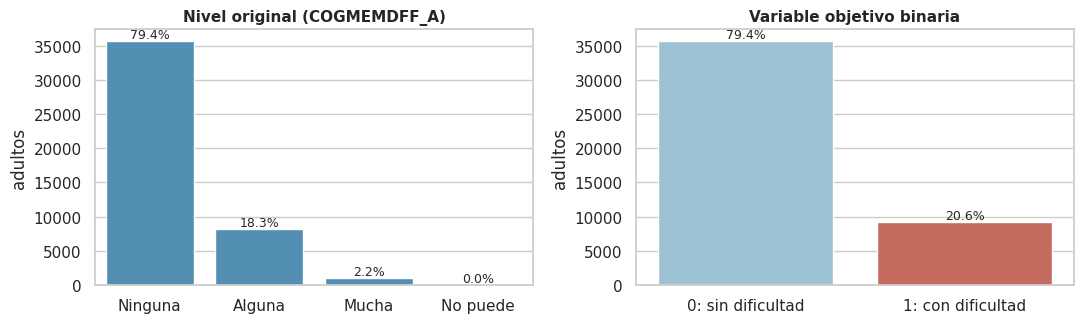

In [2]:
nivel = train["nivel_dificultad_cognitiva"].value_counts().reindex(ORDENES["nivel_dificultad_cognitiva"])
tabla_obj = pd.DataFrame({"n": nivel, "proporción": nivel / nivel.sum()})
display(tabla_obj.style.format({"n": "{:,}", "proporción": "{:.2%}"}))

binaria = y.value_counts().sort_index()
ratio = binaria[0] / binaria[1]
print(f"Clase 0 (sin dificultad): {binaria[0]:,} | Clase 1 (con dificultad): {binaria[1]:,}")
print(f"Prevalencia: {y.mean():.2%} | Razón de desbalance 0:1 = {ratio:.2f} : 1 | Casos de la clase minoritaria: {binaria[1]:,}")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
sns.barplot(x=nivel.index, y=nivel.values, ax=axes[0], color="#4393c3")
axes[0].set_title("Nivel original (COGMEMDFF_A)"); axes[0].set_xlabel(""); axes[0].set_ylabel("adultos")
for i, v in enumerate(nivel.values):
    axes[0].text(i, v, f"{v / nivel.sum():.1%}", ha="center", va="bottom", fontsize=9)
sns.barplot(x=["0: sin dificultad", "1: con dificultad"], y=binaria.values, ax=axes[1],
            palette=["#92c5de", "#d6604d"])
axes[1].set_title("Variable objetivo binaria"); axes[1].set_ylabel("adultos")
for i, v in enumerate(binaria.values):
    axes[1].text(i, v, f"{v / binaria.sum():.1%}", ha="center", va="bottom", fontsize=9)
plt.tight_layout(); plt.show()

,n,prevalencia,ic_inf,ic_sup
anio,,,,
2022,"21,722",20.42%,19.89%,20.96%
2023,"23,181",20.78%,20.26%,21.31%


Año: chi2 = 0.86, p = 0.354, V de Cramér = 0.000
Trimestre (8 periodos): chi2 = 16.21, p = 0.023, V de Cramér = 0.014


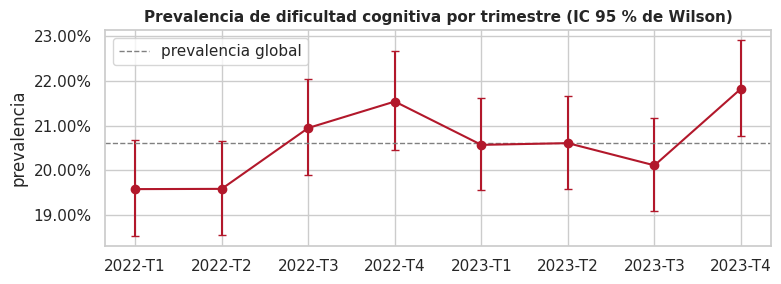

In [3]:
# Comportamiento de la variable objetivo en el tiempo (año y trimestre de entrevista)
por_anio = train.groupby("anio")[OBJETIVO].apply(prev_ic).unstack()
por_trim = train.groupby(["anio", "trimestre"])[OBJETIVO].apply(prev_ic).unstack()
display(por_anio.style.format({"n": "{:,.0f}", "prevalencia": "{:.2%}", "ic_inf": "{:.2%}", "ic_sup": "{:.2%}"}))

t_anio = pd.crosstab(train["anio"], y)
chi_a, p_a, _, _ = stats.chi2_contingency(t_anio)
t_trim = pd.crosstab(train["anio"].astype(str) + "-T" + train["trimestre"].astype(str), y)
chi_t, p_t, _, _ = stats.chi2_contingency(t_trim)
print(f"Año: chi2 = {chi_a:.2f}, p = {p_a:.3f}, V de Cramér = {cramers_v(t_anio):.3f}")
print(f"Trimestre (8 periodos): chi2 = {chi_t:.2f}, p = {p_t:.3f}, V de Cramér = {cramers_v(t_trim):.3f}")

fig, ax = plt.subplots(figsize=(8, 3))
etiquetas = [f"{a}-T{t}" for a, t in por_trim.index]
ax.errorbar(etiquetas, por_trim["prevalencia"], yerr=[por_trim["prevalencia"] - por_trim["ic_inf"],
            por_trim["ic_sup"] - por_trim["prevalencia"]], fmt="o-", capsize=3, color="#b2182b")
ax.axhline(y.mean(), ls="--", color="gray", lw=1, label="prevalencia global")
ax.set_ylabel("prevalencia"); ax.set_title("Prevalencia de dificultad cognitiva por trimestre (IC 95 % de Wilson)")
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1)); ax.legend()
plt.tight_layout(); plt.show()

### 2.2 Análisis unidimensional

#### 2.2.1 Variables numéricas

La única predictora numérica es la edad. El IMC numérico se analiza como apoyo del EDA, aunque no entra al modelo (ver 1.9.2).

La edad tiene una media de 52,9 años y una mediana de 54, con un rango de 18 a 85. Su distribución es casi simétrica (asimetría de -0,07) pero platicúrtica, con una curtosis de -1,11, es decir aproximadamente uniforme entre los 25 y los 80 años, con un pico artificial en 85 por el truncamiento. No es normal, todas las pruebas la rechazan, incluso Shapiro-Wilk en una submuestra de 500, lo que muestra que el rechazo no se debe solo al tamaño de la muestra. Esto no es un problema para una regresión logística, que no exige normalidad en las predictoras, aunque sí refuerza la decisión de escalarla dentro del pipeline.

El IMC tiene una media de 28,0 kg/m², es decir sobrepeso en promedio, con asimetría positiva (0,71) y una cola hacia la obesidad severa. Su distribución tampoco es normal, y además está recortada en los extremos por la supresión del NCHS (ver 1.9.2). Como el IMC numérico no entra al modelo, no se transforma.

In [4]:
num = train[["edad", "imc"]]
desc = num.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T
desc["asimetría"] = num.skew()
desc["curtosis (exceso)"] = num.kurt()
desc["CV"] = desc["std"] / desc["mean"]
display(desc.style.format("{:.2f}").format({"count": "{:,.0f}"}))

for var in ["edad", "imc"]:
    x = num[var].dropna()
    k2, p = stats.normaltest(x)
    x_m = x.sample(500, random_state=SEED)
    w, p_w = stats.shapiro(x_m)
    print(f"{var}: D'Agostino-Pearson K² = {k2:,.0f} (p = {p:.1e}); Shapiro-Wilk en submuestra de 500: W = {w:.3f} (p = {p_w:.1e})")

,count,mean,std,min,5%,25%,50%,75%,95%,max,asimetría,curtosis (exceso),CV
edad,"44,797",52.863473,18.402537,18.000000,23.000000,37.000000,54.000000,68.000000,82.000000,85.000000,-0.066601,-1.107622,0.348114
imc,"41,099",27.996269,5.520933,14.770000,20.360000,23.910000,27.320000,31.240000,38.390000,53.720000,0.710363,0.364166,0.197202


edad: D'Agostino-Pearson K² = 19,464 (p = 0.0e+00); Shapiro-Wilk en submuestra de 500: W = 0.961 (p = 3.7e-10)
imc: D'Agostino-Pearson K² = 2,990 (p = 0.0e+00); Shapiro-Wilk en submuestra de 500: W = 0.965 (p = 1.8e-09)


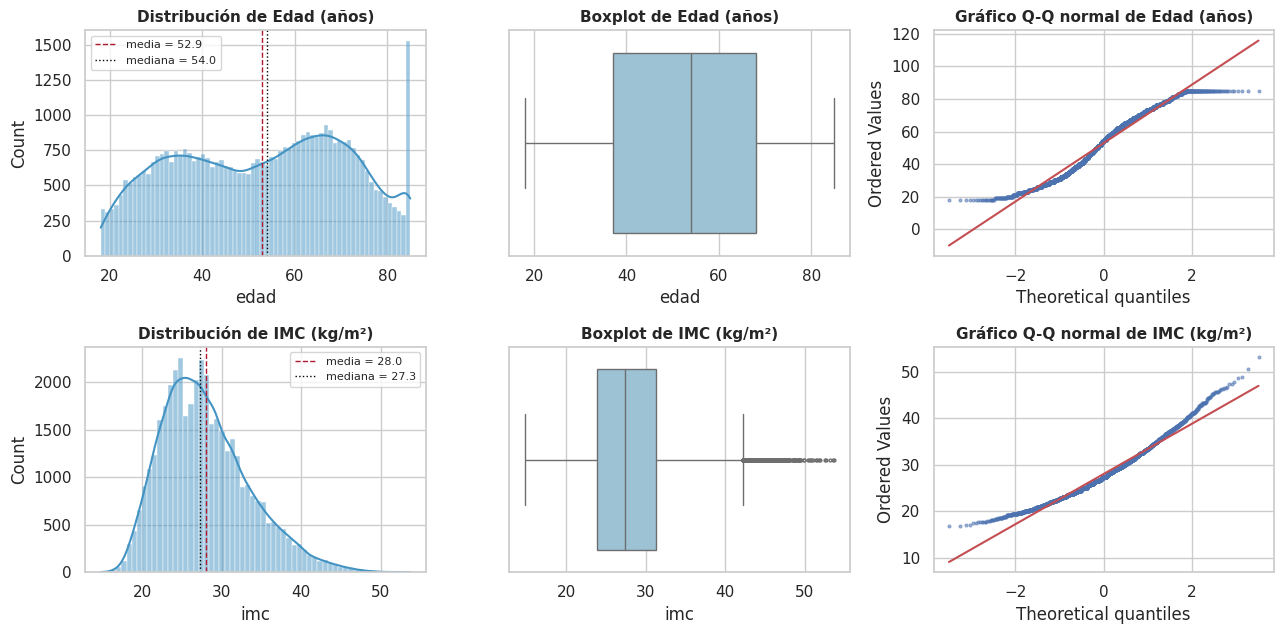

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(13, 6.5))
for fila, (var, etiqueta) in enumerate([("edad", "Edad (años)"), ("imc", "IMC (kg/m²)")]):
    x = num[var].dropna()
    sns.histplot(x, bins=68 if var == "edad" else 60, kde=True, ax=axes[fila, 0], color="#4393c3")
    axes[fila, 0].axvline(x.mean(), color="#b2182b", ls="--", lw=1, label=f"media = {x.mean():.1f}")
    axes[fila, 0].axvline(x.median(), color="black", ls=":", lw=1, label=f"mediana = {x.median():.1f}")
    axes[fila, 0].legend(fontsize=8); axes[fila, 0].set_title(f"Distribución de {etiqueta}")
    sns.boxplot(x=x, ax=axes[fila, 1], color="#92c5de", fliersize=2)
    axes[fila, 1].set_title(f"Boxplot de {etiqueta}")
    stats.probplot(x.sample(3000, random_state=SEED), dist="norm", plot=axes[fila, 2])
    axes[fila, 2].set_title(f"Gráfico Q-Q normal de {etiqueta}")
    axes[fila, 2].get_lines()[0].set(markersize=2, alpha=0.5)
plt.tight_layout(); plt.show()

#### 2.2.2 Variables categóricas

Todas las predictoras categóricas tienen cardinalidad baja, entre 2 y 7 niveles, así que la codificación one-hot no debería generar problemas de dimensionalidad. Los perfiles más frecuentes describen a un adulto sin hipertensión (62,9 %), sin diabetes (89,2 %), sin antecedente de ACV (96,5 %) y que nunca fumó (63,4 %). El ACV es la condición más rara, con 3,5 % de la muestra y unos 1.560 casos en entrenamiento, suficiente para estimar su efecto aunque con intervalos más amplios.

Hay algunas categorías raras, por debajo del 1 %, como AIAN no hispano (0,67 %) y AIAN y otro grupo (0,70 %) dentro de raza y etnia, y no puede en dificultad auditiva (0,07 %) y visual (0,11 %). Con tan pocos casos, sus coeficientes serían inestables y su prevalencia muy imprecisa, así que para el preprocesamiento se decide agrupar las categorías AIAN con otro o múltiple (1,1 %, también pequeña y heterogénea) y no puede con mucha.

In [6]:
filas = []
for v in PREDICTORAS_CAT:
    vc = train[v].value_counts(normalize=True)
    raras = vc[vc < 0.01]
    filas.append([v, DICCIONARIO.set_index("variable").loc[v, "tipo"], train[v].nunique(), vc.index[0], vc.iloc[0],
                  ", ".join(f"{c} ({p:.2%})" for c, p in raras.items()) or "—"])
resumen_cat = pd.DataFrame(filas, columns=["variable", "tipo", "cardinalidad", "moda", "% moda",
                                           "categorías raras (< 1 %)"])
display(resumen_cat.style.hide(axis="index").format({"% moda": "{:.1%}"}))

variable,tipo,cardinalidad,moda,% moda,categorías raras (< 1 %)
sexo,Nominal binaria,2,Mujer,54.5%,—
raza_etnia,Nominal (7),7,Blanco no hispano,66.1%,"AIAN y otro grupo (0.70%), AIAN no hispano (0.67%)"
educacion,Ordinal (5),5,Técnico o universidad incompleta,28.0%,—
hipertension,Binaria,2,No,62.9%,—
colesterol_alto,Binaria,2,No,68.0%,—
diabetes,Binaria,2,No,89.2%,—
acv,Binaria,2,No,96.5%,—
depresion_dx,Binaria,2,No,81.0%,—
frecuencia_depresion,Ordinal (5),5,Nunca,52.6%,—
dificultad_auditiva,Ordinal (4),4,Ninguna,82.7%,No puede (0.07%)


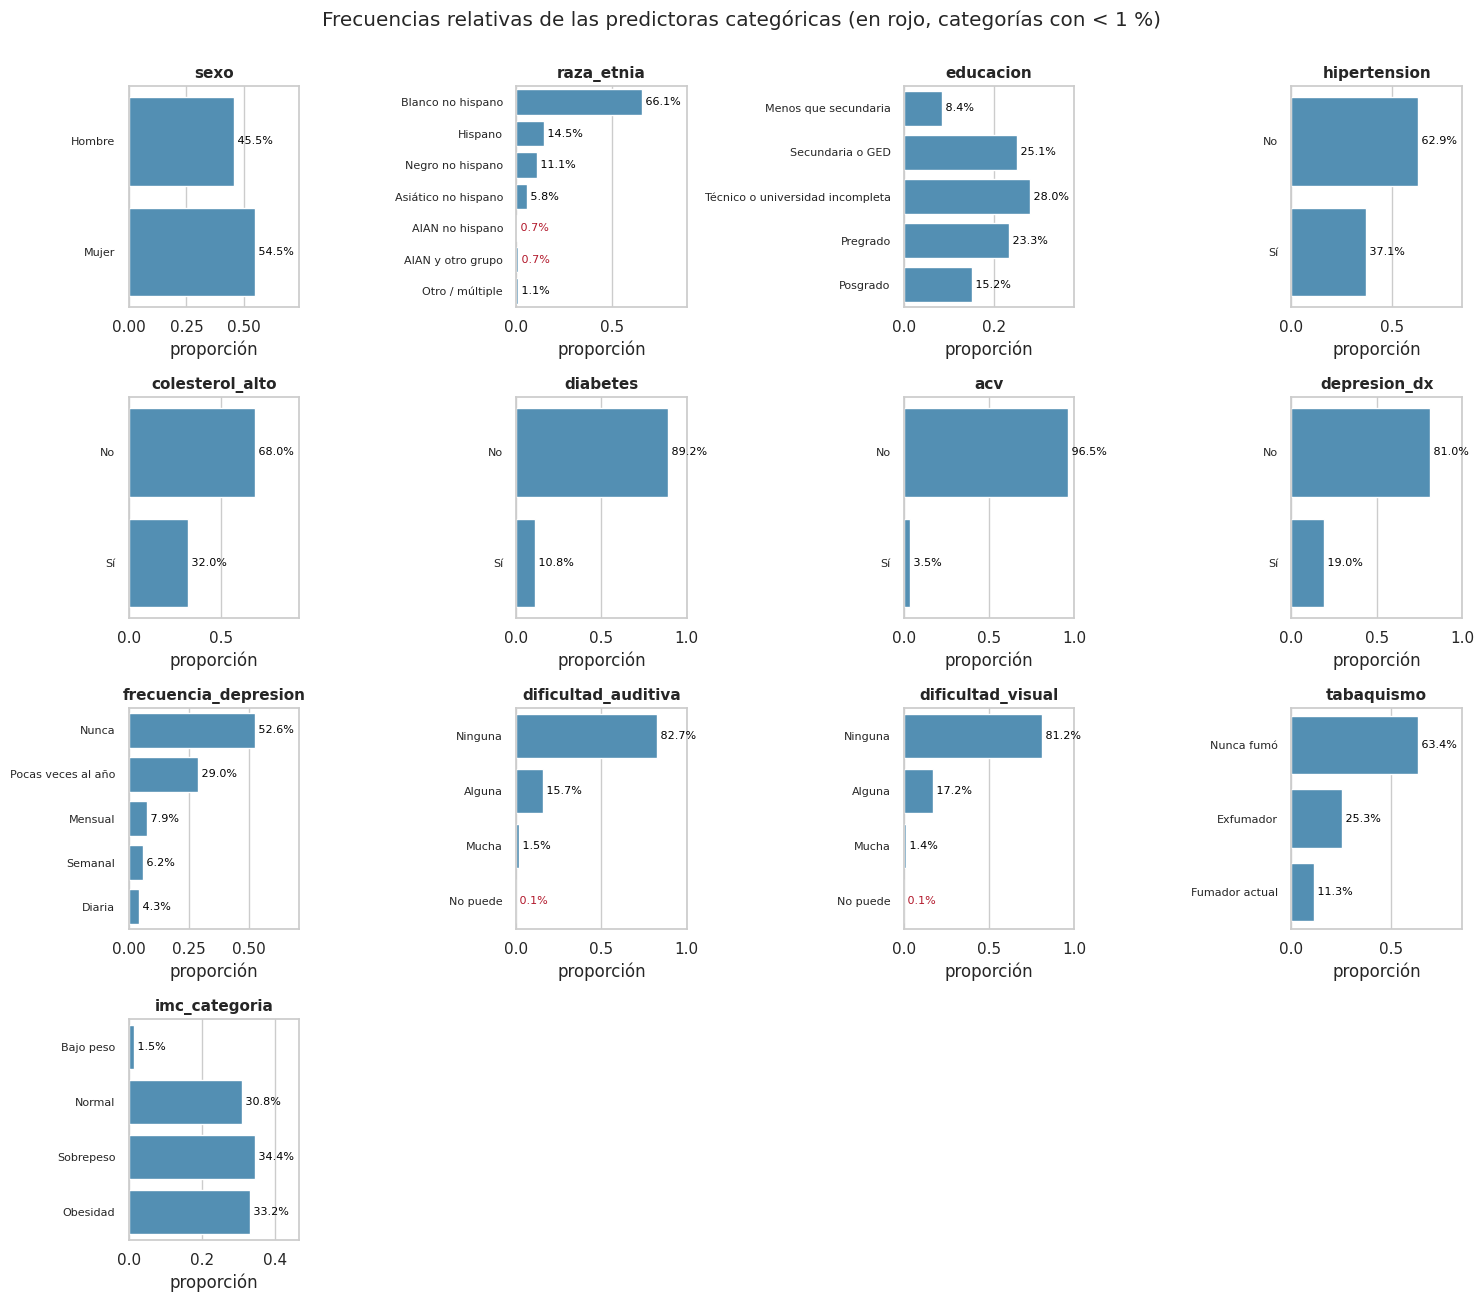

In [7]:
fig, axes = plt.subplots(4, 4, figsize=(15, 13))
for ax, v in zip(axes.ravel(), PREDICTORAS_CAT):
    orden = CATEGORIAS.get(v) or ORDENES.get(v)
    vc = train[v].value_counts(normalize=True).reindex(orden)
    sns.barplot(y=[str(c) for c in vc.index], x=vc.values, ax=ax, color="#4393c3", orient="h")
    for i, p in enumerate(vc.values):
        ax.text(p, i, f" {p:.1%}", va="center", fontsize=8, color="#b2182b" if p < 0.01 else "black")
    ax.set_title(v); ax.set_xlim(0, min(1.0, vc.max() * 1.35)); ax.set_xlabel("proporción")
    ax.tick_params(axis="y", labelsize=8)
for ax in axes.ravel()[len(PREDICTORAS_CAT):]:
    ax.axis("off")
plt.suptitle("Frecuencias relativas de las predictoras categóricas (en rojo, categorías con < 1 %)", y=1.0)
plt.tight_layout(); plt.show()

### 2.3 Análisis bidimensional

#### 2.3.1 Numéricas vs. numéricas

Edad e IMC prácticamente no están correlacionados, con Pearson r = 0,016 y Spearman ρ = 0,024. Los valores p resultan significativos solo por el enorme tamaño de la muestra, ya que una correlación de 0,02 explica menos del 0,1 % de la varianza. La mediana por quinquenio sí muestra una relación suave y no lineal, el IMC sube hasta los 50-60 años y luego baja, algo que el coeficiente lineal no logra capturar. Para el modelo esto implica que la edad y el estado nutricional aportan información no redundante.

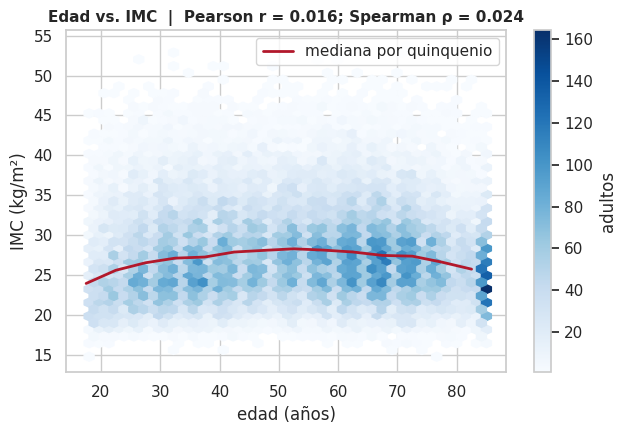

Pearson r = 0.016 (p = 1.5e-03); Spearman rho = 0.024 (p = 7.5e-07); n = 41,029


In [8]:
par = train[["edad", "imc"]].dropna()
r_p, p_p = stats.pearsonr(par["edad"], par["imc"])
r_s, p_s = stats.spearmanr(par["edad"], par["imc"])
fig, ax = plt.subplots(figsize=(6.5, 4.5))
hb = ax.hexbin(par["edad"], par["imc"], gridsize=40, cmap="Blues", mincnt=1)
plt.colorbar(hb, ax=ax, label="adultos")
medias = par.groupby(pd.cut(par["edad"], range(15, 90, 5)), observed=True)["imc"].median()
ax.plot([i.mid for i in medias.index], medias.values, color="#b2182b", lw=2, label="mediana por quinquenio")
ax.set_xlabel("edad (años)"); ax.set_ylabel("IMC (kg/m²)"); ax.legend()
ax.set_title(f"Edad vs. IMC  |  Pearson r = {r_p:.3f}; Spearman ρ = {r_s:.3f}")
plt.tight_layout(); plt.show()
print(f"Pearson r = {r_p:.3f} (p = {p_p:.1e}); Spearman rho = {r_s:.3f} (p = {p_s:.1e}); n = {len(par):,}")

#### 2.3.2 Categóricas vs. numéricas

Primero se mira la edad según la variable objetivo, luego la prevalencia de DCS por grupo de edad, que es lo que revela la forma real de la relación, y por último la edad en cada categoría de las demás predictoras, con Kruskal-Wallis y su tamaño de efecto ε².

Quienes reportan DCS son mayores, con una mediana de 61 años frente a 52, aunque el efecto es pequeño (r biserial = 0,17). El hallazgo más importante, sin embargo, está en la forma de la curva de prevalencia, que no es monótona sino en forma de U. La prevalencia es del 21 % entre los 18 y los 24 años, baja hasta un mínimo de cerca del 14 % entre los 35 y los 49, y luego sube de forma sostenida hasta el 39 % en los mayores de 79. La dificultad cognitiva de los adultos jóvenes probablemente refleja factores distintos al envejecimiento, como la atención, la ansiedad o el sueño, mientras que la de los mayores se asocia más al envejecimiento cerebral. Como un término lineal de edad no puede representar una forma de U, se decide modelar la edad con splines cúbicos dentro del pipeline.

Entre IMC y DCS la diferencia de medianas es mínima (27,6 frente a 27,2 kg/m², con r = 0,06, un efecto despreciable), lo que es coherente con la débil asociación que ya mostraba la categoría de IMC.

La edad, comparada con las demás predictoras, está fuertemente relacionada con la hipertensión (ε² = 0,19) y el colesterol alto (ε² = 0,15), quienes tienen estas condiciones son en promedio 20 años mayores. También se relaciona, aunque menos, con la pérdida auditiva (ε² = 0,06). Esto anticipa un problema de confusión por edad, porque parte de la asociación cruda de estos factores con la DCS se debe simplemente a que son marcadores de mayor edad, y el modelo multivariado tendrá que ajustar por ella.

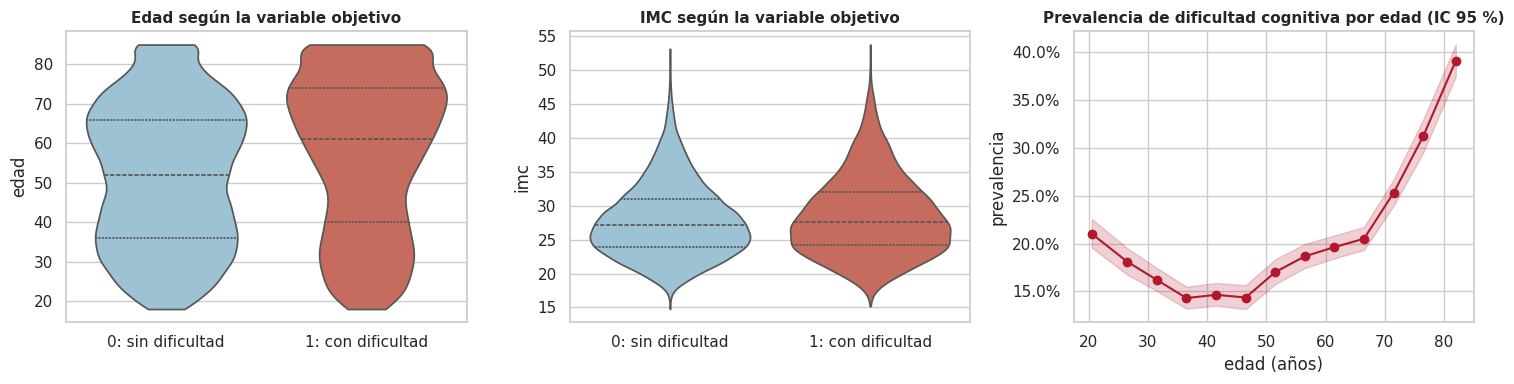

variable,mediana con dificultad,mediana sin dificultad,p (Mann-Whitney),r biserial por rangos
edad,61.0,52.0,2.0e-147,0.174
imc,27.6,27.2,2.3e-16,0.058


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.violinplot(data=train, x=OBJETIVO, y="edad", ax=axes[0], palette=["#92c5de", "#d6604d"], cut=0, inner="quartile")
axes[0].set_xticks([0, 1], ["0: sin dificultad", "1: con dificultad"]); axes[0].set_xlabel("")
axes[0].set_title("Edad según la variable objetivo")
sns.violinplot(data=train, x=OBJETIVO, y="imc", ax=axes[1], palette=["#92c5de", "#d6604d"], cut=0, inner="quartile")
axes[1].set_xticks([0, 1], ["0: sin dificultad", "1: con dificultad"]); axes[1].set_xlabel("")
axes[1].set_title("IMC según la variable objetivo")

grupos = pd.cut(train["edad"], [17, 24, 29, 34, 39, 44, 49, 54, 59, 64, 69, 74, 79, 85])
prev_edad = train.groupby(grupos, observed=True)[OBJETIVO].apply(prev_ic).unstack()
x_mid = [i.mid for i in prev_edad.index]
axes[2].plot(x_mid, prev_edad["prevalencia"], "o-", color="#b2182b")
axes[2].fill_between(x_mid, prev_edad["ic_inf"], prev_edad["ic_sup"], alpha=0.2, color="#b2182b")
axes[2].yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))
axes[2].set_xlabel("edad (años)"); axes[2].set_ylabel("prevalencia")
axes[2].set_title("Prevalencia de dificultad cognitiva por edad (IC 95 %)")
plt.tight_layout(); plt.show()

filas = []
for var in ["edad", "imc"]:
    a = train.loc[y == 1, var].dropna(); b = train.loc[y == 0, var].dropna()
    u = stats.mannwhitneyu(a, b)
    r_rb = 2 * u.statistic / (len(a) * len(b)) - 1
    filas.append([var, a.median(), b.median(), u.pvalue, r_rb])
display(pd.DataFrame(filas, columns=["variable", "mediana con dificultad", "mediana sin dificultad",
                                     "p (Mann-Whitney)", "r biserial por rangos"])
        .style.hide(axis="index").format({"p (Mann-Whitney)": "{:.1e}", "r biserial por rangos": "{:.3f}",
                                          "mediana con dificultad": "{:.1f}", "mediana sin dificultad": "{:.1f}"}))

In [10]:
filas = []
for v in PREDICTORAS_CAT:
    sub = train[[v, "edad"]].dropna()
    grupos_v = [g["edad"].values for _, g in sub.groupby(v)]
    h, p = stats.kruskal(*grupos_v)
    k, n_v = len(grupos_v), len(sub)
    eps2 = max(0.0, (h - k + 1) / (n_v - k))
    medianas = sub.groupby(v)["edad"].median()
    filas.append([v, h, p, eps2, f"{medianas.idxmin()} ({medianas.min():.0f}) → {medianas.idxmax()} ({medianas.max():.0f})"])
kw = pd.DataFrame(filas, columns=["variable", "H", "p", "ε²", "edad mediana: mín → máx"])
kw["p (Holm)"] = multipletests(kw["p"], method="holm")[1]
kw = kw.sort_values("ε²", ascending=False)
display(kw.style.hide(axis="index").format({"H": "{:,.0f}", "p": "{:.1e}", "p (Holm)": "{:.1e}", "ε²": "{:.3f}"})
        .bar(subset="ε²", color="#f4a582"))

variable,H,p,ε²,edad mediana: mín → máx,p (Holm)
hipertension,"8,626",0.0e+00,0.193,No (44) → Sí (66),0.0e+00
colesterol_alto,"6,818",0.0e+00,0.153,No (46) → Sí (66),0.0e+00
dificultad_auditiva,"2,862",0.0e+00,0.064,Ninguna (51) → Mucha (69),0.0e+00
raza_etnia,"2,558",0.0e+00,0.057,Otro / múltiple (36) → Blanco no hispano (58),0.0e+00
diabetes,"2,156",0.0e+00,0.048,No (52) → Sí (66),0.0e+00
tabaquismo,"1,941",0.0e+00,0.045,Nunca fumó (50) → Exfumador (63),0.0e+00
acv,"1,219",4.5e-267,0.027,No (53) → Sí (71),3.1e-266
frecuencia_depresion,653,4.9e-140,0.015,Mensual (45) → Nunca (57),2.9e-139
dificultad_visual,551,3.6e-119,0.012,Ninguna (52) → No puede (66),1.8e-118
educacion,434,1.1e-92,0.010,Pregrado (49) → Menos que secundaria (60),4.4e-92


#### 2.3.3 Categóricas vs. categóricas (cada predictora vs. la variable objetivo)

Tras la corrección de Holm, las 13 predictoras siguen asociadas con la DCS, todas con p menor a 10⁻²¹, así que en este punto la significación ya no discrimina nada. Lo que importa es la magnitud, medida con la V de Cramér.

El bloque más fuerte es el de salud mental. La frecuencia de síntomas depresivos tiene la asociación más alta (V = 0,31, moderada) y un gradiente dosis-respuesta muy claro, la prevalencia pasa de 11,6 % en quienes nunca se sienten deprimidos a 59,0 % en quienes se sienten así todos los días. El diagnóstico de depresión le sigue de cerca (V = 0,29; 44,5 % frente a 15,0 %).

Las pérdidas sensoriales van después. La dificultad auditiva (V = 0,25) y la visual (V = 0,23) también muestran un gradiente, con una prevalencia del 16 % sin dificultad, cerca de 40 % con alguna dificultad y de 54 a 55 % con mucha. La categoría no puede rompe el gradiente, pero sus intervalos son muy amplios por tener pocos casos, lo que confirma que agruparla fue la decisión correcta.

Los factores vasculares y de estilo de vida tienen asociaciones más pequeñas, con V entre 0,10 y 0,12, entre ellos colesterol alto (27,9 % frente a 17,2 %), hipertensión (27,0 % frente a 16,9 %), ACV (45,3 % frente a 19,7 %), diabetes, tabaquismo y baja escolaridad (28,9 % sin secundaria frente a 14,3 % con posgrado).

Raza y etnia, sexo e IMC tienen asociaciones despreciables (V < 0,08). La categoría de IMC muestra una leve forma de U, con más prevalencia en bajo peso y en obesidad que en peso normal o sobrepeso, por lo que conviene codificarla con one-hot en lugar de tratarla como variable ordinal lineal.

En conjunto, estos resultados son coherentes con la literatura. Los factores de la Comisión Lancet se asocian con la DCS en la dirección esperada, lo que respalda la validez de la variable objetivo.

In [11]:
filas = []
for v in PREDICTORAS_CAT:
    tab = pd.crosstab(train[v], y)
    chi2, p, dof, esperadas = stats.chi2_contingency(tab)
    filas.append([v, chi2, dof, p, cramers_v(tab), (esperadas < 5).sum()])
asoc = pd.DataFrame(filas, columns=["variable", "chi2", "gl", "p", "V de Cramér", "celdas esperadas < 5"])
asoc["p (Holm)"] = multipletests(asoc["p"], method="holm")[1]
asoc["magnitud"] = pd.cut(asoc["V de Cramér"], [-0.01, 0.1, 0.3, 0.5, 1], labels=["despreciable", "pequeña", "moderada", "grande"])
asoc = asoc.sort_values("V de Cramér", ascending=False)
display(asoc.style.hide(axis="index").format({"chi2": "{:,.1f}", "p": "{:.1e}", "p (Holm)": "{:.1e}",
                                              "V de Cramér": "{:.3f}"}).bar(subset="V de Cramér", color="#f4a582"))

variable,chi2,gl,p,V de Cramér,celdas esperadas < 5,p (Holm),magnitud
frecuencia_depresion,"4,327.2",4,0.0e+00,0.314,0,0.0e+00,moderada
depresion_dx,"3,664.4",1,0.0e+00,0.286,0,0.0e+00,pequeña
dificultad_auditiva,"2,688.5",3,0.0e+00,0.245,0,0.0e+00,pequeña
dificultad_visual,"2,373.8",3,0.0e+00,0.230,0,0.0e+00,pequeña
colesterol_alto,685.9,1,3.6e-151,0.124,0,3.2e-150,pequeña
hipertension,650.8,1,1.5e-143,0.120,0,1.2e-142,pequeña
acv,599.5,1,2.2e-132,0.116,0,1.5e-131,pequeña
educacion,576.3,4,2.1e-123,0.113,0,1.3e-122,pequeña
tabaquismo,493.3,2,7.5e-108,0.106,0,3.7e-107,pequeña
diabetes,420.8,1,1.6e-93,0.097,0,6.5e-93,despreciable


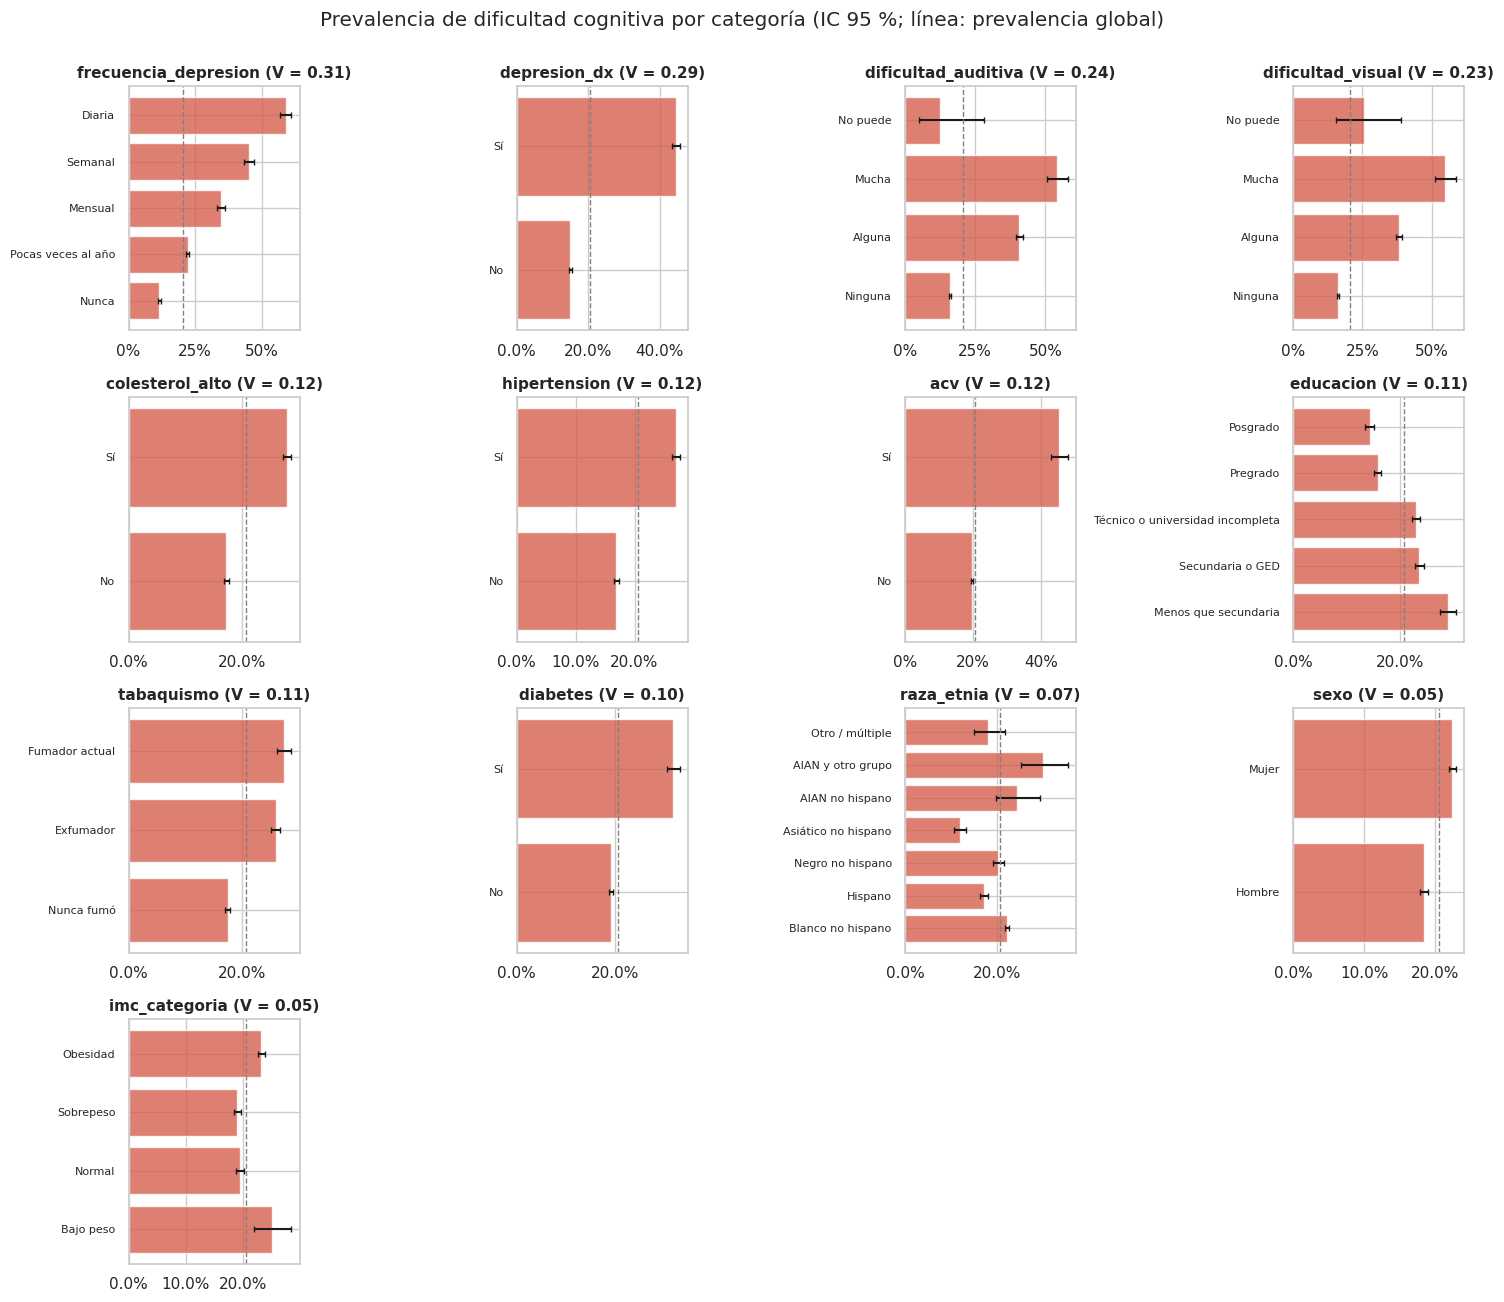

In [12]:
fig, axes = plt.subplots(4, 4, figsize=(15, 13))
for ax, v in zip(axes.ravel(), asoc["variable"]):
    orden = [c for c in (CATEGORIAS.get(v) or ORDENES.get(v)) if c in set(train[v].dropna())]
    pv = train.groupby(v)[OBJETIVO].apply(prev_ic).unstack().reindex(orden)
    ax.barh([str(c) for c in pv.index], pv["prevalencia"], xerr=[pv["prevalencia"] - pv["ic_inf"],
            pv["ic_sup"] - pv["prevalencia"]], color="#d6604d", alpha=0.8, capsize=2)
    ax.axvline(y.mean(), color="gray", ls="--", lw=1)
    ax.xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))
    ax.set_title(f"{v} (V = {asoc.set_index('variable').loc[v, 'V de Cramér']:.2f})"); ax.tick_params(axis="y", labelsize=8)
for ax in axes.ravel()[len(PREDICTORAS_CAT):]:
    ax.axis("off")
plt.suptitle("Prevalencia de dificultad cognitiva por categoría (IC 95 %; línea: prevalencia global)", y=1.0)
plt.tight_layout(); plt.show()

#### 2.3.4 La exposición de interés, el antecedente de ACV

El ACV se asocia con la edad, y la edad con la DCS, así que la asociación cruda entre ACV y DCS puede estar confundida por la edad. Para revisarlo se compara el odds ratio crudo con el odds ratio de Mantel-Haenszel, ajustado por grupo de edad.

Entre quienes tuvieron un ACV, el 45,3 % reporta DCS, frente al 19,7 % de quienes no lo tuvieron. El OR crudo es de 3,36 (IC 95 % 3,03-3,72). Pero el ACV es mucho más frecuente en edades avanzadas, con 591 casos en mayores de 75 años frente a 83 en menores de 45, y la edad también eleva por sí misma la DCS. Al ajustar por grupo de edad con Mantel-Haenszel, el OR baja a 2,52 (IC 95 % 2,27-2,80). Es decir, cerca de un tercio del exceso de odds crudo se explica por la edad, pero la asociación sigue siendo fuerte e independiente.

Además, la prueba de Breslow-Day (p < 0,001) muestra que el efecto no es homogéneo entre edades. El OR es de 4,7 en menores de 45 años y cae a 1,7 en mayores de 75. El gráfico ayuda a entender por qué, en los adultos jóvenes tener un ACV multiplica la prevalencia de DCS, de 16,5 % a 48,2 %, mientras que en los mayores de 75 la prevalencia de base ya es alta (34,3 %) y el ACV añade relativamente menos (46,7 %). Esto sugiere una interacción entre ACV y edad que un modelo lineal sin interacciones no va a capturar, y queda anotada como una oportunidad para los modelos de las siguientes entregas.

Tabla 2x2 (filas: ACV sí/no; columnas: dificultad sí/no)


dificultad_cognitiva,1,0
acv_si,,
1,705,854
0,8523,34664


OR crudo = 3.36 (IC 95 %: 3.03–3.72)
OR por grupo de edad: {'18-44': 4.72, '45-54': 3.43, '55-64': 3.83, '65-74': 2.93, '75+': 1.68}
OR de Mantel-Haenszel ajustado por edad = 2.52 (IC 95 %: 2.27–2.80)
Prueba de homogeneidad de Breslow-Day: p = 0.000


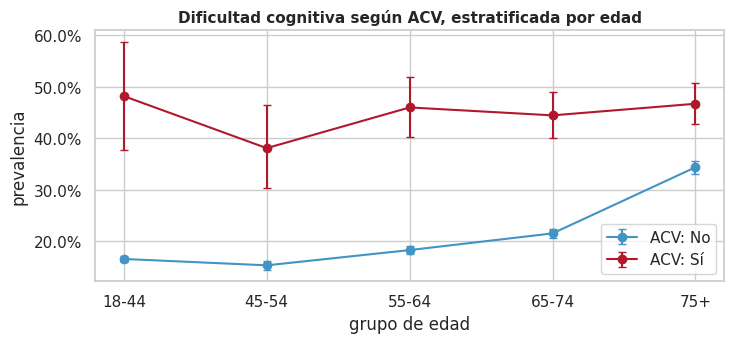

grupo_edad,18-44,45-54,55-64,65-74,75+
acv,,,,,
n (ACV No),16284,6131,7591,7775,5406
n (ACV Sí),83,134,274,477,591


In [13]:
from statsmodels.stats.contingency_tables import Table2x2, StratifiedTable

sub = train.dropna(subset=["acv", "edad"]).copy()
sub["acv_si"] = (sub["acv"] == "Sí").astype(int)
t = pd.crosstab(sub["acv_si"], sub[OBJETIVO]).loc[[1, 0], [1, 0]]
crudo = Table2x2(t.values)
print("Tabla 2x2 (filas: ACV sí/no; columnas: dificultad sí/no)"); display(t)
print(f"OR crudo = {crudo.oddsratio:.2f} (IC 95 %: {crudo.oddsratio_confint()[0]:.2f}–{crudo.oddsratio_confint()[1]:.2f})")

sub["grupo_edad"] = pd.cut(sub["edad"], [17, 44, 54, 64, 74, 85], labels=["18-44", "45-54", "55-64", "65-74", "75+"])
tablas = [pd.crosstab(g["acv_si"], g[OBJETIVO]).reindex(index=[1, 0], columns=[1, 0], fill_value=0).values
          for _, g in sub.groupby("grupo_edad", observed=True)]
mh = StratifiedTable(tablas)
or_estrato = pd.Series([Table2x2(tb + 0.5).oddsratio for tb in tablas],
                       index=sub["grupo_edad"].cat.categories, name="OR por estrato")
print("OR por grupo de edad:", or_estrato.round(2).to_dict())
print(f"OR de Mantel-Haenszel ajustado por edad = {mh.oddsratio_pooled:.2f} "
      f"(IC 95 %: {mh.oddsratio_pooled_confint()[0]:.2f}–{mh.oddsratio_pooled_confint()[1]:.2f})")
print(f"Prueba de homogeneidad de Breslow-Day: p = {mh.test_equal_odds().pvalue:.3f}")

pv = sub.groupby(["grupo_edad", "acv"], observed=True)[OBJETIVO].apply(prev_ic).unstack()
fig, ax = plt.subplots(figsize=(7.5, 3.6))
for acv, color in [("No", "#4393c3"), ("Sí", "#b2182b")]:
    d = pv.xs(acv, level="acv")
    ax.errorbar(d.index.astype(str), d["prevalencia"], yerr=[d["prevalencia"] - d["ic_inf"], d["ic_sup"] - d["prevalencia"]],
                fmt="o-", capsize=3, color=color, label=f"ACV: {acv}")
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1)); ax.legend()
ax.set_xlabel("grupo de edad"); ax.set_ylabel("prevalencia"); ax.set_title("Dificultad cognitiva según ACV, estratificada por edad")
plt.tight_layout(); plt.show()
display(pv["n"].unstack().rename(columns=lambda c: f"n (ACV {c})").astype(int).T)

#### 2.3.5 Predictoras vs. objetivo, información mutua

La información mutua captura cualquier tipo de dependencia, incluidas las que son no lineales y no monótonas, como la de la edad, que la correlación simple no logra detectar.

La información mutua ordena las predictoras casi igual que la V de Cramér. La frecuencia de síntomas depresivos, el diagnóstico de depresión y las dificultades auditiva y visual encabezan la lista, seguidas por la edad, que aquí sube hasta el quinto lugar. Esto tiene sentido, porque la edad tiene una asociación lineal débil con el objetivo (r biserial = 0,17), pero la información mutua sí detecta su relación en forma de U. Los valores absolutos son bajos en todos los casos, por debajo de 0,05 nats, lo que indica que ninguna variable por sí sola determina el objetivo. El desempeño del modelo va a depender de combinar muchas señales débiles, y no se esperan métricas cercanas a 1.

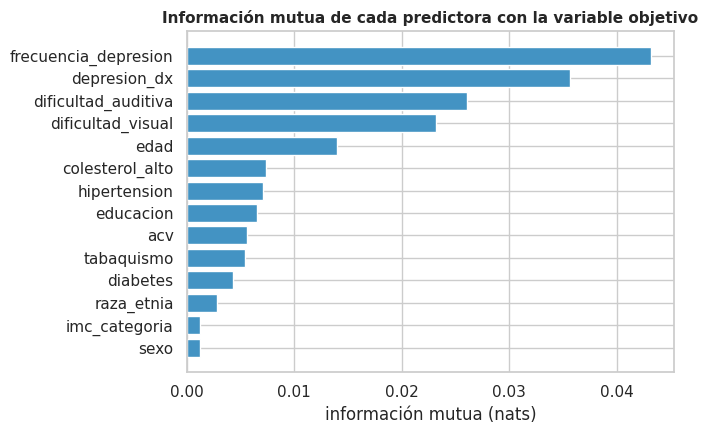

In [14]:
from sklearn.feature_selection import mutual_info_classif

X_mi = pd.DataFrame(index=train.index)
for v in PREDICTORAS_CAT:
    X_mi[v] = train[v].astype("category").cat.codes  # los faltantes quedan como categoría propia (-1)
X_mi["edad"] = train["edad"].fillna(train["edad"].median())
mi = mutual_info_classif(X_mi, y, discrete_features=[c != "edad" for c in X_mi.columns], random_state=SEED)
mi = pd.Series(mi, index=X_mi.columns).sort_values()
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.barh(mi.index, mi.values, color="#4393c3"); ax.set_xlabel("información mutua (nats)")
ax.set_title("Información mutua de cada predictora con la variable objetivo")
plt.tight_layout(); plt.show()

#### 2.3.6 Asociación entre predictoras y multicolinealidad

El par de predictoras más asociado es el diagnóstico de depresión con la frecuencia de síntomas depresivos (V = 0,58), algo esperable porque miden el mismo constructo desde dos ángulos distintos, la historia diagnóstica y los síntomas actuales. Le siguen la hipertensión con la edad (0,43) y con el colesterol alto (0,38), que es el conocido agrupamiento de riesgo cardiometabólico junto con el envejecimiento.

Aun así, no hay multicolinealidad problemática. Con las categorías de referencia del modelo, el VIF máximo es 3,38, en las categorías de educación, que son mutuamente excluyentes, y ninguna columna supera 5. La correlación de Spearman confirma que las asociaciones son como máximo moderadas. Se decide conservar ambas variables de depresión, porque aportan información distinta (sección 1.9.5), y la regularización L2 de la regresión logística amortigua cualquier inestabilidad residual en los coeficientes.

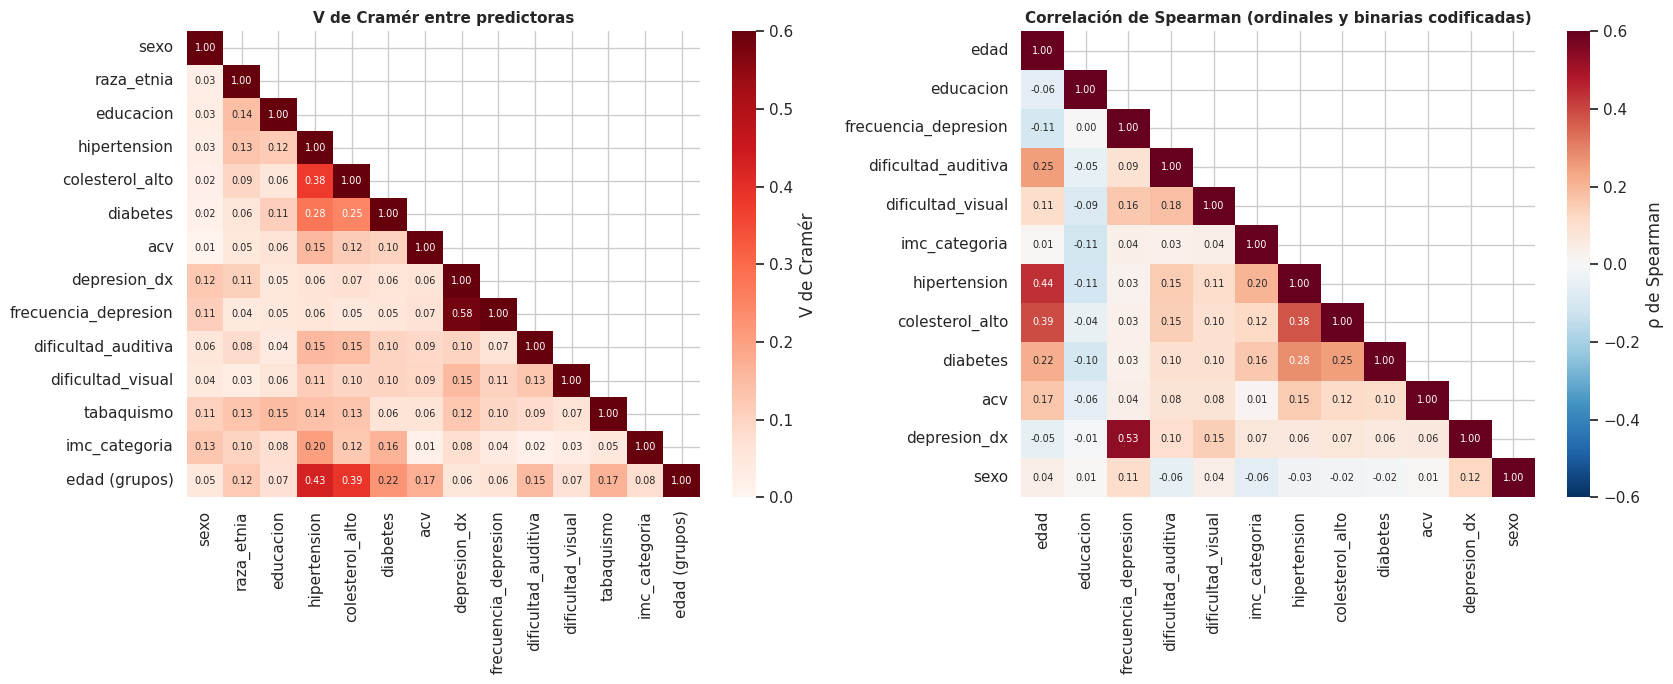

Pares con mayor asociación (V de Cramér):
depresion_dx     frecuencia_depresion   0.5840
hipertension     edad (grupos)          0.4310
colesterol_alto  edad (grupos)          0.3890
hipertension     colesterol_alto        0.3770
                 diabetes               0.2770
colesterol_alto  diabetes               0.2500


In [15]:
vars_assoc = PREDICTORAS_CAT + ["edad (grupos)"]
tmp = train[PREDICTORAS_CAT].copy()
tmp["edad (grupos)"] = pd.cut(train["edad"], [17, 34, 49, 64, 74, 85])
mat = pd.DataFrame(np.eye(len(vars_assoc)), index=vars_assoc, columns=vars_assoc)
for i, a in enumerate(vars_assoc):
    for b in vars_assoc[i + 1:]:
        mat.loc[a, b] = mat.loc[b, a] = cramers_v(pd.crosstab(tmp[a], tmp[b]))

ordinales = ["edad", "educacion", "frecuencia_depresion", "dificultad_auditiva", "dificultad_visual", "imc_categoria",
             "hipertension", "colesterol_alto", "diabetes", "acv", "depresion_dx", "sexo"]
ordn = pd.DataFrame({v: train[v] if v == "edad" else a_ordinal(train[v], v) for v in ordinales})
spear = ordn.corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(17, 7))
mask = np.triu(np.ones_like(mat, dtype=bool), 1)
sns.heatmap(mat, mask=mask, annot=True, fmt=".2f", cmap="Reds", vmin=0, vmax=0.6, ax=axes[0], annot_kws={"size": 7},
            cbar_kws={"label": "V de Cramér"})
axes[0].set_title("V de Cramér entre predictoras")
sns.heatmap(spear, mask=np.triu(np.ones_like(spear, dtype=bool), 1), annot=True, fmt=".2f", cmap="RdBu_r",
            vmin=-0.6, vmax=0.6, center=0, ax=axes[1], annot_kws={"size": 7}, cbar_kws={"label": "ρ de Spearman"})
axes[1].set_title("Correlación de Spearman (ordinales y binarias codificadas)")
plt.tight_layout(); plt.show()

pares = (mat.where(np.triu(np.ones_like(mat, dtype=bool), 1)).stack().sort_values(ascending=False).head(6))
print("Pares con mayor asociación (V de Cramér):"); print(pares.round(3).to_string())

In [16]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Para el VIF se usa la edad lineal (los splines son colineales por construcción)
completos = train[PREDICTORAS].dropna()
X_vif = dummies_referencia(completos)
X_vif["edad"] = completos["edad"]
X_vif.insert(0, "constante", 1.0)
vif = pd.Series([variance_inflation_factor(X_vif.values, i) for i in range(1, X_vif.shape[1])],
                index=X_vif.columns[1:]).sort_values(ascending=False)
display(vif.head(12).rename("VIF").to_frame().style.format("{:.2f}").bar(color="#f4a582"))
print(f"VIF máximo = {vif.max():.2f}; columnas con VIF > 5: {(vif > 5).sum()}; con VIF > 10: {(vif > 10).sum()}")

,VIF
educacion_Técnico o universidad incompleta,3.38
educacion_Pregrado,3.28
educacion_Secundaria o GED,3.15
educacion_Posgrado,2.69
edad,1.60
depresion_dx_Sí,1.57
imc_categoria_Obesidad,1.54
imc_categoria_Sobrepeso,1.44
hipertension_Sí,1.44
frecuencia_depresion_Semanal,1.32


VIF máximo = 3.38; columnas con VIF > 5: 0; con VIF > 10: 0


#### 2.3.7 Selección preliminar de variables

Con base en todo lo anterior, se conservan las 14 predictoras.

1. Todas tienen una asociación con el objetivo distinta de cero después de corregir por comparaciones múltiples.
2. Ninguna es redundante, con VIF por debajo de 5.
3. Cada una está justificada por la literatura, por el marco de la Comisión Lancet 2024, por el ACV como exposición de interés, y por la edad, el sexo y la raza o etnia como variables de ajuste.
4. Las de asociación despreciable, como sexo, IMC y raza o etnia, se mantienen como confusores, pues aunque predigan poco por sí solas, pueden modificar la estimación de los demás efectos una vez que el modelo ajusta por ellas.

La selección definitiva queda sujeta a la auditoría de fuga de datos de la sección 2.5, donde se descartan las variables que no estarían disponibles de forma legítima al momento de predecir.

In [17]:
sel = asoc.set_index("variable")[["V de Cramér", "p (Holm)"]].copy()
sel.loc["edad", "V de Cramér"] = np.nan
sel["información mutua"] = mi
sel["rango IM"] = sel["información mutua"].rank(ascending=False).astype(int)
sel["decisión preliminar"] = "Conservar"
display(sel.sort_values("rango IM").style.format({"V de Cramér": "{:.3f}", "p (Holm)": "{:.1e}",
                                                   "información mutua": "{:.4f}"}, na_rep="—"))

,V de Cramér,p (Holm),información mutua,rango IM,decisión preliminar
variable,,,,,
frecuencia_depresion,0.314,0.0e+00,0.0432,1,Conservar
depresion_dx,0.286,0.0e+00,0.0356,2,Conservar
dificultad_auditiva,0.245,0.0e+00,0.0261,3,Conservar
dificultad_visual,0.230,0.0e+00,0.0232,4,Conservar
edad,—,—,0.0140,5,Conservar
colesterol_alto,0.124,3.2e-150,0.0074,6,Conservar
hipertension,0.120,1.2e-142,0.0071,7,Conservar
educacion,0.113,1.3e-122,0.0065,8,Conservar
acv,0.116,1.5e-131,0.0056,9,Conservar


### 2.4 Análisis multivariado

#### 2.4.1 Reducción de dimensionalidad exploratoria (PCA)

El PCA se aplica a las predictoras codificadas, con one-hot y categoría de referencia, edad estandarizada y faltantes imputados con la moda, solo para este análisis exploratorio. Se usa únicamente como herramienta descriptiva, no inferencial.

La varianza está muy repartida. La primera componente explica solo el 7,7 %, las dos primeras juntas el 13,2 %, y se necesitan 22 de las 32 componentes para llegar al 80 %. Esto significa que la dimensionalidad efectiva es alta en relación con el número de variables, es decir que las predictoras son poco redundantes entre sí, algo coherente con los VIF bajos, así que reducir dimensiones no traería ninguna ventaja real.

La primera componente funciona como un eje cardiometabólico y de envejecimiento, donde cargan hipertensión, edad, colesterol, diabetes, pérdida auditiva y ACV. La segunda es más bien un eje de salud mental, donde cargan el diagnóstico de depresión y la frecuencia de síntomas, con la edad en sentido opuesto, porque los síntomas depresivos son más frecuentes en adultos jóvenes. La tercera componente se asocia principalmente al peso corporal.

En la proyección de las dos primeras componentes, los adultos con DCS tienden a ubicarse hacia valores altos de ambos ejes, pero las dos clases se superponen ampliamente. No hay una separación lineal simple, lo que vuelve a anticipar un desempeño moderado para el modelo base.

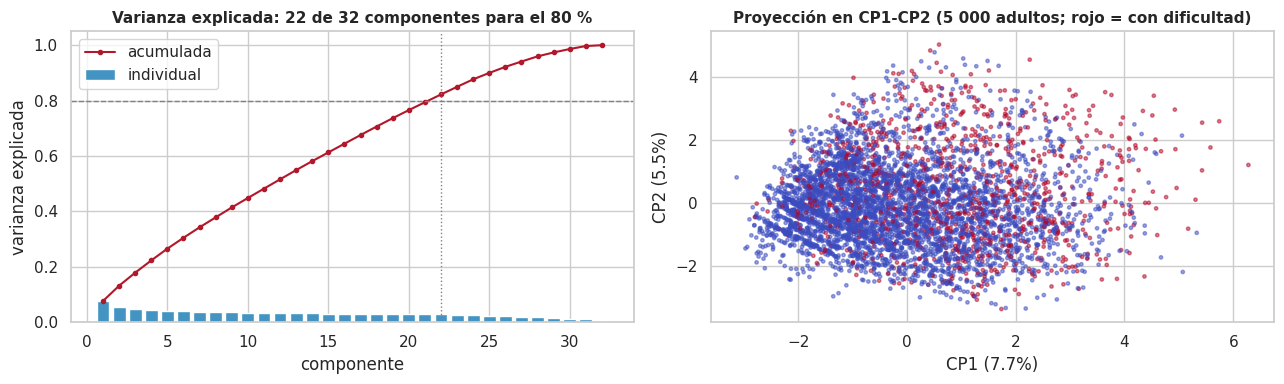

CP1 (7.7%): hipertension_Sí (+0.44), edad (+0.41), colesterol_alto_Sí (+0.39), diabetes_Sí (+0.32), dificultad_auditiva_Alguna (+0.24), acv_Sí (+0.21)
CP2 (5.5%): depresion_dx_Sí (+0.41), imc_categoria_Sobrepeso (-0.33), imc_categoria_Obesidad (+0.32), edad (-0.32), frecuencia_depresion_Diaria (+0.26), frecuencia_depresion_Semanal (+0.26)
CP3 (4.7%): imc_categoria_Obesidad (+0.51), imc_categoria_Sobrepeso (-0.45), depresion_dx_Sí (-0.39), frecuencia_depresion_Diaria (-0.24), frecuencia_depresion_Semanal (-0.24), educacion_Secundaria o GED (+0.20)
Primeras 2 componentes: 13.2% de la varianza; primeras 5: 26.6%; componentes para el 80 %: 22 de 32


In [18]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X_enc = dummies_referencia(train[PREDICTORAS_CAT].fillna(train[PREDICTORAS_CAT].mode().iloc[0]))
X_enc["edad"] = train["edad"].fillna(train["edad"].median())
X_std = StandardScaler().fit_transform(X_enc)
pca = PCA(random_state=SEED).fit(X_std)
var_acum = np.cumsum(pca.explained_variance_ratio_)
k80 = int(np.argmax(var_acum >= 0.80) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(range(1, len(var_acum) + 1), pca.explained_variance_ratio_, color="#4393c3", label="individual")
axes[0].plot(range(1, len(var_acum) + 1), var_acum, "o-", color="#b2182b", ms=3, label="acumulada")
axes[0].axhline(0.8, ls="--", color="gray", lw=1); axes[0].axvline(k80, ls=":", color="gray", lw=1)
axes[0].set_xlabel("componente"); axes[0].set_ylabel("varianza explicada"); axes[0].legend()
axes[0].set_title(f"Varianza explicada: {k80} de {len(var_acum)} componentes para el 80 %")
Z = pca.transform(X_std)[:, :2]
idx = np.random.RandomState(SEED).choice(len(Z), 5000, replace=False)
sc = axes[1].scatter(Z[idx, 0], Z[idx, 1], c=y.values[idx], cmap="coolwarm", s=6, alpha=0.5)
axes[1].set_xlabel(f"CP1 ({pca.explained_variance_ratio_[0]:.1%})"); axes[1].set_ylabel(f"CP2 ({pca.explained_variance_ratio_[1]:.1%})")
axes[1].set_title("Proyección en CP1-CP2 (5 000 adultos; rojo = con dificultad)")
plt.tight_layout(); plt.show()

cargas = pd.DataFrame(pca.components_[:3].T, index=X_enc.columns, columns=["CP1", "CP2", "CP3"])
for cp in ["CP1", "CP2", "CP3"]:
    top = cargas[cp].abs().sort_values(ascending=False).head(6).index
    print(f"{cp} ({pca.explained_variance_ratio_[int(cp[-1]) - 1]:.1%}): " +
          ", ".join(f"{c} ({cargas.loc[c, cp]:+.2f})" for c in top))
print(f"Primeras 2 componentes: {var_acum[1]:.1%} de la varianza; primeras 5: {var_acum[4]:.1%}; componentes para el 80 %: {k80} de {len(var_acum)}")

#### 2.4.2 Outliers multivariados

Con la distancia de Mahalanobis sobre edad e IMC, solo 48 adultos (0,12 %) superan el umbral del percentil 99,9, y todos tienen un IMC entre 45,7 y 53,7 kg/m², es decir obesidad severa, son valores plausibles, no errores.

Con Isolation Forest sobre todas las predictoras, el 1 % más atípico tampoco está formado por errores, sino por combinaciones raras de condiciones. El 46,9 % de este grupo tuvo un ACV, frente a 3,0 % en el resto, el 20,9 % tiene mucha dificultad visual, frente a 1,3 %, y su edad media es 9 años mayor. En este grupo la prevalencia de DCS es del 75,6 %, casi cuatro veces la del resto (20,1 %).

La decisión es no eliminarlos. Son personas reales con una alta carga de enfermedad, precisamente las más relevantes para la pregunta de investigación, y sacarlas del análisis sesgaría el modelo hacia la población más sana.

In [19]:
from sklearn.ensemble import IsolationForest

# (a) Distancia de Mahalanobis en el espacio numérico (edad, IMC)
par = train[["edad", "imc"]].dropna()
cov_inv = np.linalg.inv(np.cov(par.values.T))
dif = par.values - par.values.mean(axis=0)
d2 = np.einsum("ij,jk,ik->i", dif, cov_inv, dif)
umbral = stats.chi2.ppf(0.999, df=2)
print(f"Mahalanobis (edad, IMC): {(d2 > umbral).sum()} adultos ({(d2 > umbral).mean():.2%}) superan el percentil 99,9 de chi2(2) = {umbral:.1f}")
print("   Perfil de esos casos:", par[d2 > umbral].describe().loc[["mean", "min", "max"]].round(1).to_dict())

# (b) Isolation Forest sobre todas las predictoras codificadas
iso = IsolationForest(n_estimators=300, contamination=0.01, random_state=SEED).fit(X_std)
atipico = iso.predict(X_std) == -1
perfil = pd.DataFrame({
    "atípicos (1 %)": [atipico.sum(), y[atipico].mean(), train.loc[atipico, "edad"].mean(),
                       (train.loc[atipico, "acv"] == "Sí").mean(), (train.loc[atipico, "dificultad_visual"].isin(["Mucha", "No puede"])).mean(),
                       (train.loc[atipico, "raza_etnia"].str.contains("AIAN|Otro")).mean()],
    "resto": [(~atipico).sum(), y[~atipico].mean(), train.loc[~atipico, "edad"].mean(),
              (train.loc[~atipico, "acv"] == "Sí").mean(), (train.loc[~atipico, "dificultad_visual"].isin(["Mucha", "No puede"])).mean(),
              (train.loc[~atipico, "raza_etnia"].str.contains("AIAN|Otro")).mean()]},
    index=["n", "prevalencia de dificultad cognitiva", "edad media", "% con ACV", "% con mucha dificultad visual",
           "% raza/etnia AIAN u otra"])
display(perfil.style.format("{:.3f}").format("{:,.0f}", subset=pd.IndexSlice["n", :]))

Mahalanobis (edad, IMC): 48 adultos (0.12%) superan el percentil 99,9 de chi2(2) = 13.8
   Perfil de esos casos: {'edad': {'mean': 50.7, 'min': 18.0, 'max': 82.0}, 'imc': {'mean': 49.5, 'min': 45.7, 'max': 53.7}}


,atípicos (1 %),resto
n,450,"44,453"
prevalencia de dificultad cognitiva,0.756,0.201
edad media,61.606,52.775
% con ACV,0.469,0.030
% con mucha dificultad visual,0.209,0.013
% raza/etnia AIAN u otra,0.111,0.024


#### 2.4.3 Estructura de grupos (clustering exploratorio)

El coeficiente de silueta es bajo para todos los valores de k evaluados, entre 0,09 y 0,12. Los datos no forman grupos bien separados, sino más bien un continuo de perfiles de riesgo. Se reporta la solución de k = 6, que es la de mayor silueta en el rango evaluado, solo como descripción, sin atribuirle validez inferencial. Aun así, hay dos subpoblaciones que se distinguen con claridad.

El grupo 0, con unos 1.900 adultos, tiene un perfil de salud mental, el 80 % tiene diagnóstico de depresión, el 25 % fuma y la prevalencia de DCS llega al 59 %, casi tres veces la global. El grupo 3, con unos 8.200 adultos, tiene un perfil cardiometabólico y de mayor edad, con edad media de 70 años, 90 % con hipertensión y 15 % con ACV, con una prevalencia del 35 %.

Los otros cuatro grupos son adultos más jóvenes y sanos, con prevalencias entre 13 % y 17 %. Esto sugiere que existen al menos dos rutas distintas hacia la DCS, una afectiva y otra vascular y de envejecimiento, algo que un modelo lineal aditivo captura solo parcialmente y que los modelos no lineales podrían aprovechar mejor en las siguientes entregas.

In [20]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

Zk = pca.transform(X_std)[:, :k80]
idx_s = np.random.RandomState(SEED).choice(len(Zk), 6000, replace=False)
sil = {}
for k in range(2, 7):
    km = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit(Zk)
    sil[k] = silhouette_score(Zk[idx_s], km.labels_[idx_s])
k_opt = max(sil, key=sil.get)
print("Silueta por k:", {k: round(v, 3) for k, v in sil.items()}, "-> k elegido =", k_opt)

km = KMeans(n_clusters=k_opt, n_init=10, random_state=SEED).fit(Zk)
g = pd.Series(km.labels_, index=train.index, name="cluster")
perfil_c = train.assign(cluster=g).groupby("cluster").agg(
    n=(OBJETIVO, "size"), prevalencia=(OBJETIVO, "mean"), edad_media=("edad", "mean"),
    hipertension=("hipertension", lambda s: (s == "Sí").mean()), depresion_dx=("depresion_dx", lambda s: (s == "Sí").mean()),
    mujeres=("sexo", lambda s: (s == "Mujer").mean()), fumador_actual=("tabaquismo", lambda s: (s == "Fumador actual").mean()),
    acv=("acv", lambda s: (s == "Sí").mean()))
display(perfil_c.style.format("{:.2f}").format({"n": "{:,}"}).background_gradient(subset=["prevalencia"], cmap="Reds"))

Silueta por k: {2: 0.098, 3: 0.099, 4: 0.09, 5: 0.09, 6: 0.122} -> k elegido = 6


,n,prevalencia,edad_media,hipertension,depresion_dx,mujeres,fumador_actual,acv
cluster,,,,,,,,
0,"1,907",0.590456,52.481890,0.493970,0.802307,0.609858,0.245936,0.090718
1,"9,635",0.172081,48.134527,0.243280,0.172081,0.569175,0.124650,0.005605
2,"9,343",0.133255,48.211249,0.233116,0.142460,0.539334,0.050412,0.006208
3,"8,166",0.353172,69.795711,0.896155,0.225569,0.543963,0.097845,0.145114
4,"6,351",0.125020,52.936463,0.277122,0.158243,0.562903,0.028814,0.007558
5,"9,501",0.162720,47.682130,0.220714,0.120724,0.502789,0.190717,0.004421


### 2.6 a 2.8 Componentes temporal, espacial y espacio-temporal

- 2.6 Temporal, no aplica. El dataset no es una serie de tiempo. No hay mediciones repetidas de las mismas personas ni una variable de fecha u hora con dependencia temporal, solo se conocen el año y el trimestre de la entrevista. Aun así, la sección 2.1 ya verificó que la prevalencia del objetivo es estable entre años y trimestres, sin deriva, y la partición se estratificó por año.
- 2.7 Espacial, no aplica. Los archivos de uso público no incluyen coordenadas de latitud y longitud por confidencialidad. La única geografía disponible es la región censal, que no se usa.
- 2.8 Espacio-temporal, no aplica, por las dos razones anteriores.

La ruta de trabajo corresponde entonces a la ruta A de clasificación, sin componentes adicionales.

## Capitulo 3. Auditoria de fuga de datos y preprocesamiento

Este capítulo cubre la auditoría de fuga de datos y el preprocesamiento de las variables. Igual que en el EDA, todo se calcula solo con el conjunto de entrenamiento, definido en la sección 1.7.

In [1]:
import sys, warnings
from pathlib import Path
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

from src.utils import *

estilo_graficos()
np.random.seed(SEED)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, SplineTransformer, StandardScaler

train, test = cargar_particiones()
y = train[OBJETIVO]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

### 2.5 Auditoría de fuga de datos (data leakage)

#### 2.5.1 Disponibilidad de cada variable en el momento de la predicción

El escenario de uso es un adulto del que se conoce su perfil de factores de riesgo, datos que podrían estar en una historia clínica o un formulario de ingreso, y del que todavía no se sabe si tiene dificultad cognitiva. Una variable es legítima solo si estaría disponible en ese momento, sin conocer todavía la respuesta.

In [2]:
auditoria = pd.DataFrame([
    ("edad, sexo, raza_etnia", "Sí", "Datos sociodemográficos básicos, conocidos antes de cualquier evaluación.", "Usar"),
    ("educacion", "Sí", "Dato sociodemográfico estable; se registra en la historia clínica.", "Usar"),
    ("hipertension, colesterol_alto, diabetes, acv", "Sí",
     "Diagnósticos previos ('alguna vez le dijeron...'); anteceden a la pregunta de cognición.", "Usar"),
    ("depresion_dx", "Sí", "Diagnóstico previo registrable en la historia clínica.", "Usar"),
    ("frecuencia_depresion", "Sí",
     "Síntoma afectivo medido con una pregunta distinta; no menciona memoria ni concentración.", "Usar (en observación)"),
    ("dificultad_auditiva, dificultad_visual", "Sí",
     "Funcionamiento sensorial, medible con tamizajes auditivos/visuales independientes.", "Usar (en observación)"),
    ("tabaquismo, imc_categoria", "Sí", "Hábitos y antropometría de rutina.", "Usar"),
    ("frecuencia_dificultad_cog", "No",
     "Pregunta de seguimiento que solo existe si la respuesta al objetivo fue 'sí': contiene el objetivo.", "Descartar"),
    ("discapacidad", "No",
     "Indicador construido por el NCHS a partir de 6 preguntas, una de ellas la pregunta objetivo.", "Descartar"),
    ("demencia_dx", "Parcial",
     "Por definición implica deterioro cognitivo: es un proxy clínico del objetivo, no un factor de riesgo.", "Descartar"),
    ("PHQ-8 ítem 7: 'problemas para concentrarse' (solo 2022)", "No",
     "Mide casi el mismo constructo que el objetivo; además solo existe en 2022 (no se cargó).", "Descartar"),
    ("id_hogar", "—", "Identificador aleatorio: no tiene significado y podría memorizarse.", "Descartar"),
    ("anio, trimestre", "Sí", "Metadatos de la entrevista; sin valor causal. Solo para estratificar.", "No usar como predictor"),
    ("peso_muestral, imc (numérico)", "Sí", "Diseño muestral / variable con faltante MNAR (1.9.2).", "No usar como predictor"),
], columns=["variable(s)", "¿disponible al predecir?", "justificación", "decisión"])
display(auditoria.style.hide(axis="index").set_properties(**{"text-align": "left"}))

variable(s),¿disponible al predecir?,justificación,decisión
"edad, sexo, raza_etnia",Sí,"Datos sociodemográficos básicos, conocidos antes de cualquier evaluación.",Usar
educacion,Sí,Dato sociodemográfico estable; se registra en la historia clínica.,Usar
"hipertension, colesterol_alto, diabetes, acv",Sí,Diagnósticos previos ('alguna vez le dijeron...'); anteceden a la pregunta de cognición.,Usar
depresion_dx,Sí,Diagnóstico previo registrable en la historia clínica.,Usar
frecuencia_depresion,Sí,Síntoma afectivo medido con una pregunta distinta; no menciona memoria ni concentración.,Usar (en observación)
"dificultad_auditiva, dificultad_visual",Sí,"Funcionamiento sensorial, medible con tamizajes auditivos/visuales independientes.",Usar (en observación)
"tabaquismo, imc_categoria",Sí,Hábitos y antropometría de rutina.,Usar
frecuencia_dificultad_cog,No,Pregunta de seguimiento que solo existe si la respuesta al objetivo fue 'sí': contiene el objetivo.,Descartar
discapacidad,No,"Indicador construido por el NCHS a partir de 6 preguntas, una de ellas la pregunta objetivo.",Descartar
demencia_dx,Parcial,"Por definición implica deterioro cognitivo: es un proxy clínico del objetivo, no un factor de riesgo.",Descartar


#### 2.5.2 Desempeño univariado de cada variable (AUC con validación cruzada)

Para cada variable se entrena una regresión logística usando solo esa variable, con one-hot y los faltantes como categoría propia, y splines para la edad, y se estima su ROC-AUC con validación cruzada estratificada de 5 particiones sobre el entrenamiento. Un AUC cercano a 1 es señal de alerta, porque una sola variable no debería poder adivinar un fenómeno multifactorial.

La auditoría cuantitativa confirma la sospecha conceptual sobre `frecuencia_dificultad_cog`, que por sí sola alcanza un AUC de 0,929, algo imposible para un factor de riesgo legítimo. No es que prediga el objetivo, es que lo contiene, porque su categoría de no aplica equivale a responder que no a la pregunta de DCS. Si se hubiera incluido, el modelo habría superado artificialmente el umbral de 0,90 que la guía señala como alerta, y el resultado habría sido pura fuga.

Las demás variables están lejos de ese umbral. Las 14 predictoras tienen AUC univariados entre 0,527 para el ACV y 0,684 para la frecuencia de síntomas depresivos, un rango esperable para factores de riesgo de un fenómeno multifactorial. El ACV tiene el AUC univariado más bajo a pesar de su OR alto, porque solo afecta al 3,5 % de la muestra, identifica bien a los pocos casos que tiene, pero no discrimina en la mayoría.

Hay dos resultados que muestran por qué esta auditoría no puede hacerse solo con números. La variable `discapacidad` tiene un AUC de apenas 0,608, que por sí solo no dispararía ninguna alarma, pero se construye con la misma pregunta de DCS, ya que quien responde mucha dificultad o no puede en cognición queda clasificado automáticamente con discapacidad, así que es fuga por construcción. La variable `demencia_dx` tiene un AUC de 0,515 porque la demencia es rara (0,8 %), pero conceptualmente sigue siendo un proxy del objetivo.

Los metadatos de año y trimestre tienen un AUC cercano a 0,50, es decir que no contienen información del objetivo, lo que confirma de nuevo la ausencia de deriva temporal.

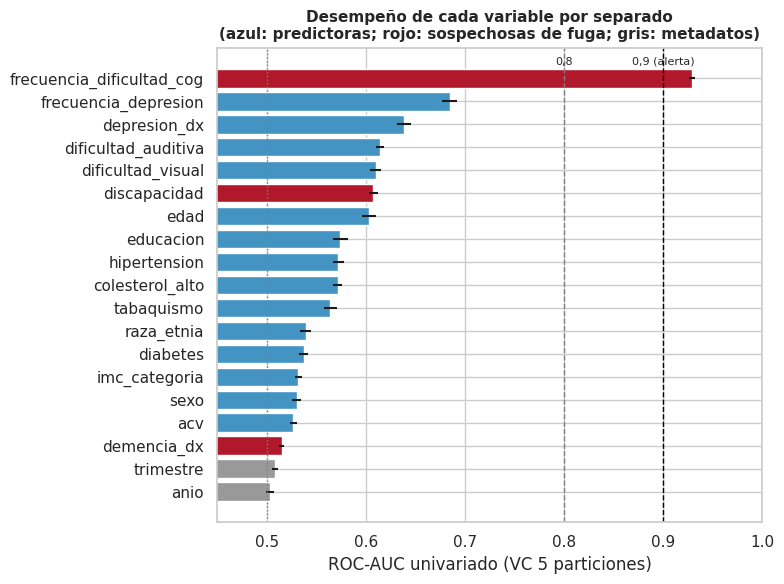

,AUC,de,grupo
frecuencia_dificultad_cog,0.929,0.003,Sospechosa
frecuencia_depresion,0.684,0.008,Predictora
depresion_dx,0.639,0.007,Predictora
dificultad_auditiva,0.614,0.004,Predictora
dificultad_visual,0.610,0.006,Predictora
discapacidad,0.608,0.005,Sospechosa
edad,0.603,0.007,Predictora
educacion,0.574,0.007,Predictora
hipertension,0.572,0.005,Predictora
colesterol_alto,0.571,0.005,Predictora


In [3]:
def auc_univariado(col):
    X = train[[col]].copy()
    if col == "edad":
        pre = Pipeline([("imp", SimpleImputer(strategy="median")), ("sp", SplineTransformer(n_knots=4)), ("esc", StandardScaler())])
    else:
        X[col] = X[col].map(str).replace({"nan": "Faltante"})
        pre = OneHotEncoder(handle_unknown="ignore")
    modelo = Pipeline([("pre", pre), ("lr", LogisticRegression(max_iter=2000))])
    s = cross_val_score(modelo, X, y, cv=cv, scoring="roc_auc")
    return s.mean(), s.std()

candidatas = PREDICTORAS + SOSPECHOSAS + ["anio", "trimestre"]
res = {c: auc_univariado(c) for c in candidatas}
auc_uni = pd.DataFrame(res, index=["AUC", "de"]).T.sort_values("AUC")
auc_uni["grupo"] = ["Sospechosa" if c in SOSPECHOSAS else ("Metadato" if c in ["anio", "trimestre"] else "Predictora")
                    for c in auc_uni.index]

fig, ax = plt.subplots(figsize=(8, 6))
colores = auc_uni["grupo"].map({"Predictora": "#4393c3", "Sospechosa": "#b2182b", "Metadato": "#999999"})
ax.barh(auc_uni.index, auc_uni["AUC"], xerr=auc_uni["de"], color=colores)
for lim, txt in [(0.8, "0,8"), (0.9, "0,9 (alerta)")]:
    ax.axvline(lim, ls="--", color="black" if lim == 0.9 else "gray", lw=1)
    ax.text(lim, len(auc_uni) - 0.4, txt, ha="center", fontsize=8)
ax.axvline(0.5, ls=":", color="gray", lw=1)
ax.set_xlim(0.45, 1.0); ax.set_xlabel("ROC-AUC univariado (VC 5 particiones)")
ax.set_title("Desempeño de cada variable por separado\n(azul: predictoras; rojo: sospechosas de fuga; gris: metadatos)")
plt.tight_layout(); plt.show()
display(auc_uni.sort_values("AUC", ascending=False).style.format({"AUC": "{:.3f}", "de": "{:.3f}"}))

#### 2.5.3 Duplicados y entidades repetidas entre entrenamiento y prueba

No hay entidades repetidas entre entrenamiento y prueba. Ningún adulto, entendido como la combinación de año y hogar, aparece en ambos conjuntos, y como hay un solo adulto por hogar no existe riesgo de que información de una misma persona o familia cruce la partición.

Sí hay perfiles compartidos. El 26,0 % de las filas de prueba tiene exactamente la misma combinación de predictoras que alguna fila de entrenamiento. Con 13 variables categóricas esto es inevitable y no constituye fuga, por dos razones que el código verifica. La primera es que son personas distintas, ya que los perfiles compartidos son los más comunes, es decir los de adultos sanos, y su prevalencia de DCS es de solo 8,4 %, frente a 24,9 % en los perfiles nuevos. La segunda es que memorizar la etiqueta mayoritaria de cada perfil en entrenamiento acierta el 86,6 % de las veces en esas filas, menos que predecir siempre la clase 0 (91,6 %). Un perfil repetido no regala la respuesta.

In [4]:
clave_tr = set(zip(train["anio"], train["id_hogar"]))
clave_te = set(zip(test["anio"], test["id_hogar"]))
print(f"Adultos (año + hogar) presentes en ambos conjuntos: {len(clave_tr & clave_te)}")

perf = lambda df: df[PREDICTORAS].apply(lambda s: s.map(str)).agg("|".join, axis=1)
p_tr, p_te = perf(train), perf(test)
en_train = p_te.isin(set(p_tr))
print(f"Filas de prueba cuyo perfil de predictoras también aparece en entrenamiento: {en_train.sum():,} ({en_train.mean():.2%})")

# ¿Esos perfiles compartidos 'regalan' la etiqueta? Se compara la etiqueta de prueba con la
# prevalencia de ese mismo perfil en entrenamiento.
prev_perfil = train.assign(p=p_tr).groupby("p")[OBJETIVO].mean()
comp = test.loc[en_train, [OBJETIVO]].assign(prev_train=p_te[en_train].map(prev_perfil).values)
acierto_memoria = ((comp["prev_train"] >= 0.5).astype(int) == comp[OBJETIVO]).mean()
print(f"Acierto de 'memorizar' la etiqueta mayoritaria del perfil en entrenamiento: {acierto_memoria:.2%} "
      f"(vs. {1 - comp[OBJETIVO].mean():.2%} de predecir siempre la clase 0 en ese subconjunto)")
print(f"Prevalencia en filas de prueba con perfil compartido: {comp[OBJETIVO].mean():.2%}; "
      f"con perfil nuevo: {test.loc[~en_train, OBJETIVO].mean():.2%}")

Adultos (año + hogar) presentes en ambos conjuntos: 0


Filas de prueba cuyo perfil de predictoras también aparece en entrenamiento: 2,917 (25.98%)
Acierto de 'memorizar' la etiqueta mayoritaria del perfil en entrenamiento: 86.60% (vs. 91.64% de predecir siempre la clase 0 en ese subconjunto)
Prevalencia en filas de prueba con perfil compartido: 8.36%; con perfil nuevo: 24.90%


#### 2.5.4 Resultado de la auditoría

El conjunto final de predictoras queda en 14 variables, todas disponibles al momento de predecir. Se descartan tres variables por fuga, una detectada de forma numérica y conceptual, y dos solo de forma conceptual, además de los identificadores y los metadatos.

Quedan en observación tres predictoras legítimas, pero con un riesgo menor que conviene vigilar. La frecuencia de síntomas depresivos, porque es la más potente de todas, ya que la depresión puede alterar la concentración y la percepción de la propia memoria, así que parte de su efecto puede ser superposición de síntomas y no un factor de riesgo en sentido estricto. Y las dificultades auditiva y visual, porque se preguntan con la misma escala del Washington Group que el objetivo, lo que puede generar correlación por estilo de respuesta, es decir personas que tienden a reportar más dificultades en general.

En las siguientes entregas se puede cuantificar ese riesgo comparando el desempeño del modelo con y sin estas variables, mediante un análisis de sensibilidad.

In [5]:
resultado = pd.DataFrame([
    ("frecuencia_dificultad_cog", "Descartada", f"AUC univariado = {auc_uni.loc['frecuencia_dificultad_cog', 'AUC']:.3f}; contiene el objetivo (faltante estructural)."),
    ("discapacidad", "Descartada", f"AUC univariado = {auc_uni.loc['discapacidad', 'AUC']:.3f}; se construye con la pregunta objetivo."),
    ("demencia_dx", "Descartada", "Proxy clínico del objetivo (demencia = deterioro cognitivo), aunque su AUC es bajo por ser rara."),
    ("id_hogar, anio, trimestre, peso_muestral", "Descartadas como predictoras", "Identificador y metadatos sin valor explicativo."),
    ("frecuencia_depresion", "En observación", "Mayor AUC entre predictoras, pero muy por debajo del umbral de alerta y conceptualmente distinta."),
    ("dificultad_auditiva, dificultad_visual", "En observación", "Mismo formato de respuesta que el objetivo (Washington Group): posible sesgo de estilo de respuesta."),
    ("Las 10 predictoras restantes", "Conservadas",
     "Disponibles al predecir y con AUC univariado entre {:.3f} y {:.3f}.".format(
         *auc_uni.loc[[c for c in PREDICTORAS if c not in ["frecuencia_depresion", "dificultad_auditiva", "dificultad_visual"]], "AUC"].agg(["min", "max"]))),
], columns=["variable(s)", "estado", "justificación"])
display(resultado.style.hide(axis="index").set_properties(**{"text-align": "left"}))

variable(s),estado,justificación
frecuencia_dificultad_cog,Descartada,AUC univariado = 0.929; contiene el objetivo (faltante estructural).
discapacidad,Descartada,AUC univariado = 0.608; se construye con la pregunta objetivo.
demencia_dx,Descartada,"Proxy clínico del objetivo (demencia = deterioro cognitivo), aunque su AUC es bajo por ser rara."
"id_hogar, anio, trimestre, peso_muestral",Descartadas como predictoras,Identificador y metadatos sin valor explicativo.
frecuencia_depresion,En observación,"Mayor AUC entre predictoras, pero muy por debajo del umbral de alerta y conceptualmente distinta."
"dificultad_auditiva, dificultad_visual",En observación,Mismo formato de respuesta que el objetivo (Washington Group): posible sesgo de estilo de respuesta.
Las 10 predictoras restantes,Conservadas,Disponibles al predecir y con AUC univariado entre 0.527 y 0.639.


### 2.9 Preprocesamiento

Todo el preprocesamiento está implementado en un `Pipeline` de scikit-learn (`src/preprocesamiento.py`) que se ajusta solo con el conjunto de entrenamiento. Dentro de la validación cruzada del modelo se reajusta en cada partición, de modo que ninguna estadística de validación o de prueba se filtra al entrenamiento. Cada decisión de preprocesamiento se puede rastrear hasta un hallazgo concreto del EDA.

El pipeline transforma las 14 predictoras en 35 columnas sin ningún valor faltante, 5 de splines para la edad, 27 one-hot, una por cada categoría distinta de la referencia, y 3 indicadores de faltante. La base de splines muestra cómo queda modelada la edad. En lugar de un único coeficiente, como sería una recta, el modelo combina 5 curvas locales cuyos nudos se ubican en los cuantiles de la edad del entrenamiento, lo que le permite reproducir la forma en U que se vio en el EDA.

El preprocesamiento tiene tres garantías contra la fuga de información. La mediana, la moda, las posiciones de los nudos y las medias y desviaciones del escalado se calculan solo con el entrenamiento. Dentro de la validación cruzada, el pipeline completo se reajusta en cada partición. Y el conjunto de prueba solo se transforma, nunca se ajusta, y eso ocurre al final, en la evaluación.

Las categorías de referencia se eligieron para que cada odds ratio se lea de forma natural, por ejemplo tener hipertensión frente a no tenerla, o sentirse deprimido a diario frente a nunca.

In [6]:
decisiones = pd.DataFrame([
    ("Códigos 7/8/9 (se negó, no determinado, no sabe) → faltante", "Codebook NHIS", "src/utils.py (antes de la partición; no aprende de los datos)"),
    ("Excluir entrevistas por proxy", "1.4: el objetivo es dificultad percibida por la propia persona", "src/utils.py"),
    ("Agrupar AIAN y 'Otro / múltiple' en una categoría", "2.2.2: categorías < 1 % con estimaciones inestables", "FunctionTransformer"),
    ("Agrupar 'No puede' con 'Mucha' en audición y visión", "2.2.2 y 2.3.3: < 0,2 % y prevalencia con IC muy amplio", "FunctionTransformer"),
    ("Imputar categóricas con la moda", "1.9.1–1.9.2: faltantes < 3 %, mecanismo MAR", "SimpleImputer(most_frequent)"),
    ("Indicador de faltante en frecuencia_depresion, tabaquismo e imc_categoria", "1.9.2: faltante asociado a año, sexo y objetivo (no MCAR)", "MissingIndicator"),
    ("Imputar edad con la mediana", "1.9.1: 0,24 % de faltantes", "SimpleImputer(median)"),
    ("Splines cúbicos para la edad (4 nudos)", "2.3.2: relación en U con la prevalencia", "SplineTransformer"),
    ("Escalar la base de splines", "Regularización L2 sensible a la escala", "StandardScaler"),
    ("One-hot con categoría de referencia para todas las categóricas (incl. ordinales)", "2.3.3: relaciones no lineales (U en IMC, 'No puede' fuera del gradiente)", "OneHotEncoder(drop='first')"),
    ("Referencias: 'No', 'Nunca', 'Ninguna', 'Normal', 'Blanco no hispano', 'Hombre', 'Menos que secundaria'", "Categorías más frecuentes o clínicamente neutras: odds ratios interpretables", "categorías explícitas"),
    ("Usar imc_categoria y no el IMC numérico", "1.9.2: faltante MNAR del IMC numérico (8,5 %) vs. 2,2 %", "selección de variables"),
    ("No eliminar ni recortar outliers", "1.9.4 y 2.4.2: valores plausibles y perfiles reales de alto riesgo", "—"),
    ("No reducir dimensionalidad", "2.4.1: varianza muy repartida, VIF < 5", "—"),
    ("Excluir variables con fuga", "2.5: AUC univariado ≈ 1 o construidas con el objetivo", "selección de variables"),
], columns=["decisión", "hallazgo que la motiva", "implementación"])
display(decisiones.style.hide(axis="index").set_properties(**{"text-align": "left"}))

decisión,hallazgo que la motiva,implementación
"Códigos 7/8/9 (se negó, no determinado, no sabe) → faltante",Codebook NHIS,src/utils.py (antes de la partición; no aprende de los datos)
Excluir entrevistas por proxy,1.4: el objetivo es dificultad percibida por la propia persona,src/utils.py
Agrupar AIAN y 'Otro / múltiple' en una categoría,2.2.2: categorías < 1 % con estimaciones inestables,FunctionTransformer
Agrupar 'No puede' con 'Mucha' en audición y visión,"2.2.2 y 2.3.3: < 0,2 % y prevalencia con IC muy amplio",FunctionTransformer
Imputar categóricas con la moda,"1.9.1–1.9.2: faltantes < 3 %, mecanismo MAR",SimpleImputer(most_frequent)
"Indicador de faltante en frecuencia_depresion, tabaquismo e imc_categoria","1.9.2: faltante asociado a año, sexo y objetivo (no MCAR)",MissingIndicator
Imputar edad con la mediana,"1.9.1: 0,24 % de faltantes",SimpleImputer(median)
Splines cúbicos para la edad (4 nudos),2.3.2: relación en U con la prevalencia,SplineTransformer
Escalar la base de splines,Regularización L2 sensible a la escala,StandardScaler
One-hot con categoría de referencia para todas las categóricas (incl. ordinales),"2.3.3: relaciones no lineales (U en IMC, 'No puede' fuera del gradiente)",OneHotEncoder(drop='first')


In [7]:
from src.preprocesamiento import construir_preprocesador

pre = construir_preprocesador()
X_tr = pre.fit_transform(train[PREDICTORAS])
nombres = [n.split("__", 1)[1] for n in pre.get_feature_names_out()]
print(f"Matriz de entrenamiento transformada: {X_tr.shape[0]:,} filas x {X_tr.shape[1]} columnas")
print(f"Valores faltantes tras el preprocesamiento: {np.isnan(X_tr).sum()}")
print("\nColumnas generadas:")
for i in range(0, len(nombres), 3):
    print("   " + " | ".join(nombres[i:i + 3]))
display(pd.DataFrame(X_tr[:5], columns=nombres).round(2))

Matriz de entrenamiento transformada: 44,903 filas x 35 columnas
Valores faltantes tras el preprocesamiento: 0

Columnas generadas:
   edad_sp_0 | edad_sp_1 | edad_sp_2
   edad_sp_3 | edad_sp_4 | sexo_Mujer
   raza_etnia_Hispano | raza_etnia_Negro no hispano | raza_etnia_Asiático no hispano
   raza_etnia_Otro / múltiple (incl. AIAN) | educacion_Secundaria o GED | educacion_Técnico o universidad incompleta
   educacion_Pregrado | educacion_Posgrado | hipertension_Sí
   colesterol_alto_Sí | diabetes_Sí | acv_Sí
   depresion_dx_Sí | frecuencia_depresion_Pocas veces al año | frecuencia_depresion_Mensual
   frecuencia_depresion_Semanal | frecuencia_depresion_Diaria | dificultad_auditiva_Alguna
   dificultad_auditiva_Mucha o no puede | dificultad_visual_Alguna | dificultad_visual_Mucha o no puede
   tabaquismo_Exfumador | tabaquismo_Fumador actual | imc_categoria_Bajo peso
   imc_categoria_Sobrepeso | imc_categoria_Obesidad | missingindicator_frecuencia_depresion
   missingindicator_tabaquis

,edad_sp_0,edad_sp_1,edad_sp_2,edad_sp_3,edad_sp_4,sexo_Mujer,raza_etnia_Hispano,raza_etnia_Negro no hispano,raza_etnia_Asiático no hispano,raza_etnia_Otro / múltiple (incl. AIAN),educacion_Secundaria o GED,educacion_Técnico o universidad incompleta,educacion_Pregrado,educacion_Posgrado,hipertension_Sí,colesterol_alto_Sí,diabetes_Sí,acv_Sí,depresion_dx_Sí,frecuencia_depresion_Pocas veces al año,frecuencia_depresion_Mensual,frecuencia_depresion_Semanal,frecuencia_depresion_Diaria,dificultad_auditiva_Alguna,dificultad_auditiva_Mucha o no puede,dificultad_visual_Alguna,dificultad_visual_Mucha o no puede,tabaquismo_Exfumador,tabaquismo_Fumador actual,imc_categoria_Bajo peso,imc_categoria_Sobrepeso,imc_categoria_Obesidad,missingindicator_frecuencia_depresion,missingindicator_tabaquismo,missingindicator_imc_categoria
0,-0.3500,-0.4100,1.1400,0.0000,-0.7500,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000
1,-0.3500,-0.6800,-1.0300,1.1200,0.6400,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000
2,-0.3500,-0.6500,0.2500,0.9200,-0.5500,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000
3,-0.3500,-0.4100,1.1400,0.0000,-0.7500,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000
4,-0.3500,0.0400,1.4600,-0.6800,-0.7700,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000


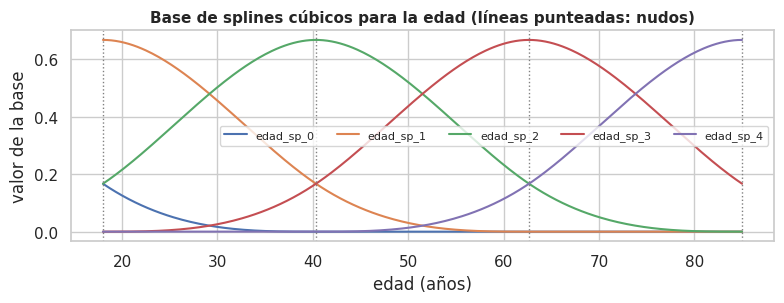

In [8]:
# Visualización de la base de splines aprendida para la edad (nudos ubicados en cuantiles del entrenamiento)
sp = pre.named_transformers_["num"].named_steps["spline"]
edades = np.linspace(18, 85, 300).reshape(-1, 1)
base = sp.transform(edades)
fig, ax = plt.subplots(figsize=(8, 3.2))
for j in range(base.shape[1]):
    ax.plot(edades, base[:, j], label=f"edad_sp_{j}")
for nudo in sp.bsplines_[0].t[3:-3]:
    ax.axvline(nudo, color="gray", ls=":", lw=1)
ax.set_xlabel("edad (años)"); ax.set_ylabel("valor de la base"); ax.legend(fontsize=8, ncol=5)
ax.set_title("Base de splines cúbicos para la edad (líneas punteadas: nudos)")
plt.tight_layout(); plt.show()

## Capitulo 4. Modelo base

Este capítulo cubre la regresión logística como modelo base, comparada contra una línea base trivial (`DummyClassifier`), con entrenamiento mediante `Pipeline`, validación cruzada estratificada, evaluación en el conjunto de prueba reservado, intervalos de confianza bootstrap, curva de aprendizaje e interpretación de coeficientes.

La variable objetivo es `dificultad_cognitiva`, donde 1 significa alguna, mucha o no puede recordar o concentrarse, y 0 significa ninguna dificultad, con una prevalencia del 20,6 %.

Se usa la partición definida en la sección 1.7, antes de cualquier preprocesamiento, con 80 % de entrenamiento (44.903) y 20 % de prueba (11.226), estratificada por objetivo y por año. El conjunto de prueba no se usa para elegir hiperparámetros ni el umbral de decisión, se abre una sola vez, al final del proceso.

Como la clase positiva es minoritaria, con un desbalance de 3,85 a 1, la métrica principal es la PR-AUC o average precision, cuya referencia trivial es la prevalencia. Se reportan además el ROC-AUC, el recall, la precisión, el F1 y el balanced accuracy de la clase positiva, junto con el Brier score y la curva de calibración. El accuracy se muestra una sola vez, en la comparación con la línea base, para mostrar por qué no es una métrica informativa con clases desbalanceadas.

In [1]:
import sys, warnings
from pathlib import Path
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

from src.utils import *

estilo_graficos()
np.random.seed(SEED)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

import joblib
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_predict, cross_validate, learning_curve
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, average_precision_score, balanced_accuracy_score, brier_score_loss,
                             confusion_matrix, f1_score, precision_recall_curve, precision_score, recall_score,
                             roc_auc_score, roc_curve)
from sklearn.calibration import calibration_curve
from src.preprocesamiento import construir_preprocesador

train, test = cargar_particiones()
X_tr, y_tr = train[PREDICTORAS], train[OBJETIVO].values
X_te, y_te = test[PREDICTORAS], test[OBJETIVO].values
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
print(f"Entrenamiento: {len(X_tr):,} ({y_tr.mean():.2%} positivos) | Prueba: {len(X_te):,} ({y_te.mean():.2%} positivos)")

Entrenamiento: 44,903 (20.61% positivos) | Prueba: 11,226 (20.60% positivos)


### 3.1 Línea base trivial

Se usan dos clasificadores triviales que no miran las predictoras en absoluto.

- `prior`, que asigna a todos la probabilidad igual a la prevalencia del entrenamiento y predice siempre la clase mayoritaria, es decir 0.
- `stratified`, que predice al azar respetando la proporción de clases.

In [2]:
puntuaciones = {"PR-AUC": "average_precision", "ROC-AUC": "roc_auc", "F1": "f1", "Recall": "recall",
                "Balanced acc.": "balanced_accuracy", "Brier (neg.)": "neg_brier_score"}
filas = []
for estrategia in ["prior", "stratified"]:
    r = cross_validate(DummyClassifier(strategy=estrategia, random_state=SEED), X_tr, y_tr, cv=cv, scoring=puntuaciones)
    filas.append([f"Dummy ({estrategia})"] + [f"{r['test_' + k].mean():.3f} ± {r['test_' + k].std():.3f}" for k in puntuaciones])
cv_dummy = pd.DataFrame(filas, columns=["modelo"] + list(puntuaciones)).set_index("modelo")
display(cv_dummy)

,PR-AUC,ROC-AUC,F1,Recall,Balanced acc.,Brier (neg.)
modelo,,,,,,
Dummy (prior),0.206 ± 0.000,0.500 ± 0.000,0.000 ± 0.000,0.000 ± 0.000,0.500 ± 0.000,-0.164 ± 0.000
Dummy (stratified),0.205 ± 0.000,0.498 ± 0.001,0.201 ± 0.002,0.200 ± 0.002,0.498 ± 0.001,-0.327 ± 0.001


### 3.2 Entrenamiento de la regresión logística con `Pipeline` y validación cruzada

El pipeline une el preprocesamiento de la sección 2.9 con la regresión logística con regularización L2. Se buscan dos hiperparámetros con validación cruzada estratificada de 5 particiones sobre el entrenamiento, del mismo tipo que la partición usada para reservar el conjunto de prueba.

- `C`, el inverso de la fuerza de regularización, probado entre 0,001 y 10.
- `class_weight`, sin ponderar o `balanced`, que pondera la clase minoritaria.

El criterio de selección es la PR-AUC media.

La línea base trivial obtiene en validación cruzada una PR-AUC de 0,206, igual a la prevalencia, y un ROC-AUC de 0,50, tal como se espera de un modelo que no usa las predictoras. La regresión logística alcanza una PR-AUC de validación de 0,519 ± 0,010 y un ROC-AUC de 0,793, es decir más del doble de la PR-AUC trivial.

Sobre los hiperparámetros, la regularización tiene un desempeño prácticamente idéntico para C entre 0,1 y 10, y solo empeora con una regularización muy fuerte (C = 0,001). Con más de 1.000 observaciones por parámetro, la regularización apenas hace falta, así que se elige C = 1. En cuanto a la ponderación de clases, usar `balanced` no mejora la PR-AUC (0,5186 frente a 0,5193) pero empeora bastante la calibración, con un Brier de 0,183 frente a 0,131, porque infla artificialmente las probabilidades de la clase positiva. Por eso se prefiere el modelo sin ponderar, y el desbalance se maneja más bien con el umbral de decisión (sección 3.3). Finalmente, no hay sobreajuste, ya que la PR-AUC de entrenamiento (0,521) es casi igual a la de validación (0,519).

In [3]:
modelo = Pipeline([("pre", construir_preprocesador()),
                   ("lr", LogisticRegression(max_iter=5000, random_state=SEED))])
rejilla = {"lr__C": [0.001, 0.01, 0.1, 1, 10], "lr__class_weight": [None, "balanced"]}
busqueda = GridSearchCV(modelo, rejilla, cv=cv, n_jobs=-1, refit="PR-AUC", return_train_score=True,
                        scoring={"PR-AUC": "average_precision", "ROC-AUC": "roc_auc", "Brier": "neg_brier_score"})
busqueda.fit(X_tr, y_tr)

res = pd.DataFrame(busqueda.cv_results_)
tabla_cv = pd.DataFrame({
    "C": res["param_lr__C"].astype(float),
    "class_weight": res["param_lr__class_weight"].map(lambda v: "balanced" if v == "balanced" else "ninguno"),
    "PR-AUC (val.)": res["mean_test_PR-AUC"], "de PR-AUC": res["std_test_PR-AUC"],
    "PR-AUC (entr.)": res["mean_train_PR-AUC"], "ROC-AUC (val.)": res["mean_test_ROC-AUC"],
    "Brier (val.)": -res["mean_test_Brier"]}).sort_values("PR-AUC (val.)", ascending=False)
display(tabla_cv.style.hide(axis="index").format(precision=4).highlight_max(subset=["PR-AUC (val.)"], color="#fddbc7"))
print("Mejores hiperparámetros:", busqueda.best_params_)
mejor = busqueda.best_estimator_

C,class_weight,PR-AUC (val.),de PR-AUC,PR-AUC (entr.),ROC-AUC (val.),Brier (val.)
1.0000,ninguno,0.5193,0.0104,0.5213,0.7934,0.1308
10.0000,ninguno,0.5193,0.0104,0.5214,0.7934,0.1308
0.1000,ninguno,0.5189,0.0104,0.5209,0.7934,0.1308
10.0000,balanced,0.5186,0.0106,0.5204,0.7935,0.1826
1.0000,balanced,0.5186,0.0106,0.5203,0.7935,0.1826
0.1000,balanced,0.5182,0.0104,0.5199,0.7934,0.1827
0.0100,ninguno,0.5134,0.0100,0.5151,0.7914,0.1315
0.0100,balanced,0.5132,0.0101,0.5148,0.7918,0.1840
0.0010,balanced,0.4905,0.0097,0.4913,0.7808,0.1944
0.0010,ninguno,0.4874,0.0093,0.4881,0.7783,0.1382


Mejores hiperparámetros: {'lr__C': 1, 'lr__class_weight': None}


### 3.3 Umbral de decisión

La regresión logística entrega probabilidades, y para clasificar hace falta fijar un umbral. El umbral por defecto de 0,5 no es óptimo con clases desbalanceadas, así que se elige el umbral que maximiza el F1 en las predicciones fuera de partición, es decir out-of-fold, del entrenamiento, de modo que el conjunto de prueba no interviene para nada en esta decisión.

Con el umbral por defecto de 0,5, el F1 out-of-fold sería de solo 0,391, porque el modelo casi nunca asigna probabilidades tan altas a una clase que representa apenas el 20 % de los casos. El umbral que maximiza el F1 en entrenamiento es 0,246, con una precisión de 0,457 y un recall de 0,627. Tiene sentido con la prevalencia observada, porque con clases desbalanceadas el umbral óptimo suele estar cerca de la proporción de positivos. Este umbral se fija antes de mirar siquiera el conjunto de prueba.

La gráfica muestra el compromiso de siempre, bajar el umbral detecta más casos, sube el recall, pero a costa de más falsas alarmas, baja la precisión. En un uso de tamizaje, donde perder un caso real es más costoso que evaluar de más a alguien sano, podría elegirse un umbral todavía menor, aunque esa decisión depende del contexto de uso y no solo de la estadística.

Umbral que maximiza el F1 out-of-fold: 0.246 (F1 = 0.529; precisión = 0.457; recall = 0.627)
F1 out-of-fold con el umbral por defecto de 0,5: 0.391


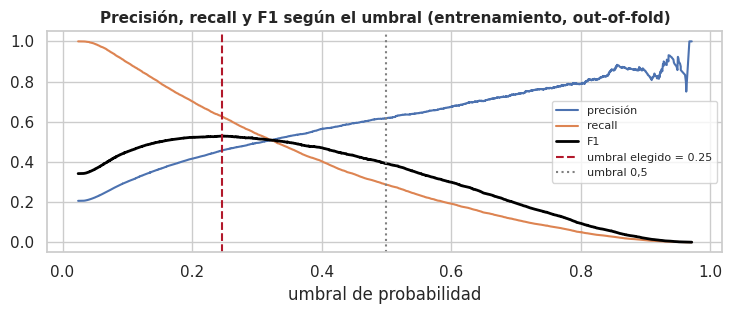

In [4]:
p_oof = cross_val_predict(mejor, X_tr, y_tr, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]
prec, rec, umbrales = precision_recall_curve(y_tr, p_oof)
f1s = 2 * prec[:-1] * rec[:-1] / np.clip(prec[:-1] + rec[:-1], 1e-12, None)
umbral = float(umbrales[np.argmax(f1s)])
print(f"Umbral que maximiza el F1 out-of-fold: {umbral:.3f} (F1 = {f1s.max():.3f}; "
      f"precisión = {prec[np.argmax(f1s)]:.3f}; recall = {rec[np.argmax(f1s)]:.3f})")
print(f"F1 out-of-fold con el umbral por defecto de 0,5: {f1_score(y_tr, p_oof >= 0.5):.3f}")

fig, ax = plt.subplots(figsize=(7.5, 3.3))
ax.plot(umbrales, prec[:-1], label="precisión"); ax.plot(umbrales, rec[:-1], label="recall")
ax.plot(umbrales, f1s, label="F1", lw=2, color="black")
ax.axvline(umbral, ls="--", color="#b2182b", label=f"umbral elegido = {umbral:.2f}")
ax.axvline(0.5, ls=":", color="gray", label="umbral 0,5")
ax.set_xlabel("umbral de probabilidad"); ax.set_title("Precisión, recall y F1 según el umbral (entrenamiento, out-of-fold)")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

### 3.4 Evaluación en el conjunto de prueba y comparación con la línea base

Aquí se abre por primera y única vez el conjunto de prueba. Los intervalos de confianza del 95 % se obtienen con bootstrap no paramétrico, con 1.000 remuestreos del conjunto de prueba y el método de percentiles.

En el conjunto de prueba, la regresión logística obtiene una PR-AUC de 0,538 [0,517-0,561], frente a 0,206 de la línea base, es decir 2,6 veces la referencia trivial. El ROC-AUC es de 0,804 [0,794-0,814], lo que significa que si se toma al azar una persona con DCS y otra sin ella, el modelo le asigna mayor probabilidad a la primera el 80 % de las veces. Con el umbral elegido, el recall es de 0,637 y la precisión de 0,461, el modelo detecta casi dos de cada tres casos, y cerca de la mitad de sus alertas resultan correctas, frente a una de cada cinco que se obtendría por azar. El F1 es de 0,535 y el balanced accuracy de 0,722.

La mejora sobre el Dummy estratificado es clara y significativa en todas las métricas, por ejemplo +0,330 en PR-AUC, con un IC 95 % de 0,309 a 0,351 que no incluye el cero. Las métricas de prueba son además coherentes con las de validación cruzada (PR-AUC 0,519 ± 0,010), la pequeña diferencia está dentro de la variabilidad esperada, lo que confirma que el modelo generaliza razonablemente bien.

Aquí aparece la trampa clásica del accuracy. El Dummy mayoritario obtiene un accuracy de 0,794, mayor que el de la regresión logística (0,772), pero sin detectar un solo caso, con recall igual a 0. Es exactamente el escenario que advierte la guía, y la razón por la que el accuracy no se usa para decidir nada aquí.

Todas las métricas quedan por debajo de 0,90, con un margen amplio de mejora, lo que hace de este un problema adecuado para comparar modelos más complejos en las siguientes entregas.

De los 2.313 adultos con DCS en el conjunto de prueba, el modelo identifica correctamente a 1.474 (63,7 %) y no detecta a 839. De los 8.913 sin dificultad, clasifica bien a 7.190, con una especificidad de 0,807, y genera 1.723 falsas alarmas. En total marca como positivos al 28,5 % de los adultos. El valor predictivo negativo es de 0,896, es decir que cuando el modelo dice que no hay dificultad, acierta en casi 9 de cada 10 casos, lo que lo hace bastante útil para descartar.

La curva ROC está claramente por encima de la diagonal del azar en todo el rango, sin cruces con la línea base. La curva de precisión-recall es la más informativa cuando hay desbalance, la precisión parte cerca de 0,8 para los adultos con mayor probabilidad predicha y va cayendo a medida que se exige más recall, siempre muy por encima de la línea de la prevalencia (0,206). El punto marcado en la gráfica corresponde al compromiso elegido.

In [5]:
dummy_prior = DummyClassifier(strategy="prior").fit(X_tr, y_tr)
dummy_strat = DummyClassifier(strategy="stratified", random_state=SEED).fit(X_tr, y_tr)
p_lr = mejor.predict_proba(X_te)[:, 1]
modelos_prob = {"Dummy (prior)": dummy_prior.predict_proba(X_te)[:, 1],
                "Dummy (stratified)": dummy_strat.predict_proba(X_te)[:, 1],
                "Regresión logística": p_lr}
modelos_pred = {"Dummy (prior)": dummy_prior.predict(X_te), "Dummy (stratified)": dummy_strat.predict(X_te),
                "Regresión logística": (p_lr >= umbral).astype(int)}

def metricas(y, p, yhat):
    return {"PR-AUC": average_precision_score(y, p), "ROC-AUC": roc_auc_score(y, p) if len(set(p)) > 1 else 0.5,
            "Recall": recall_score(y, yhat, zero_division=0), "Precisión": precision_score(y, yhat, zero_division=0),
            "F1": f1_score(y, yhat, zero_division=0), "Balanced acc.": balanced_accuracy_score(y, yhat),
            "Brier": brier_score_loss(y, p), "Accuracy": accuracy_score(y, yhat)}

rng = np.random.RandomState(SEED)
B = 1000
idx_boot = [rng.randint(0, len(y_te), len(y_te)) for _ in range(B)]
tabla, boots = {}, {}
for nombre in modelos_prob:
    p, yhat = modelos_prob[nombre], modelos_pred[nombre]
    punto = metricas(y_te, p, yhat)
    bs = pd.DataFrame([metricas(y_te[i], p[i], yhat[i]) for i in idx_boot])
    boots[nombre] = bs
    tabla[nombre] = {k: f"{v:.3f} [{bs[k].quantile(0.025):.3f}–{bs[k].quantile(0.975):.3f}]" for k, v in punto.items()}
tabla = pd.DataFrame(tabla)
display(tabla.style.set_caption("Métricas en el conjunto de prueba: valor [IC 95 % bootstrap]"))

dif = boots["Regresión logística"] - boots["Dummy (stratified)"]
print("Mejora de la regresión logística sobre el Dummy estratificado (IC 95 % bootstrap):")
for k in ["PR-AUC", "ROC-AUC", "F1", "Recall", "Balanced acc."]:
    print(f"   {k}: +{dif[k].mean():.3f} [{dif[k].quantile(0.025):.3f}–{dif[k].quantile(0.975):.3f}]")

,Dummy (prior),Dummy (stratified),Regresión logística
PR-AUC,0.206 [0.199–0.214],0.208 [0.200–0.217],0.538 [0.517–0.561]
ROC-AUC,0.500 [0.500–0.500],0.507 [0.497–0.517],0.804 [0.794–0.814]
Recall,0.000 [0.000–0.000],0.214 [0.197–0.234],0.637 [0.619–0.657]
Precisión,0.000 [0.000–0.000],0.217 [0.199–0.237],0.461 [0.445–0.480]
F1,0.000 [0.000–0.000],0.216 [0.199–0.234],0.535 [0.520–0.552]
Balanced acc.,0.500 [0.500–0.500],0.507 [0.497–0.517],0.722 [0.712–0.733]
Brier,0.164 [0.159–0.168],0.321 [0.313–0.330],0.128 [0.124–0.132]
Accuracy,0.794 [0.786–0.801],0.679 [0.670–0.687],0.772 [0.764–0.780]


Mejora de la regresión logística sobre el Dummy estratificado (IC 95 % bootstrap):
   PR-AUC: +0.330 [0.309–0.351]
   ROC-AUC: +0.297 [0.284–0.311]
   F1: +0.320 [0.298–0.342]
   Recall: +0.423 [0.397–0.448]
   Balanced acc.: +0.215 [0.201–0.230]


VP = 1,474 | FN = 839 | FP = 1,723 | VN = 7,190 | especificidad = 0.807 | VPN = 0.896 | positivos predichos = 3,197 (28.5% del total)


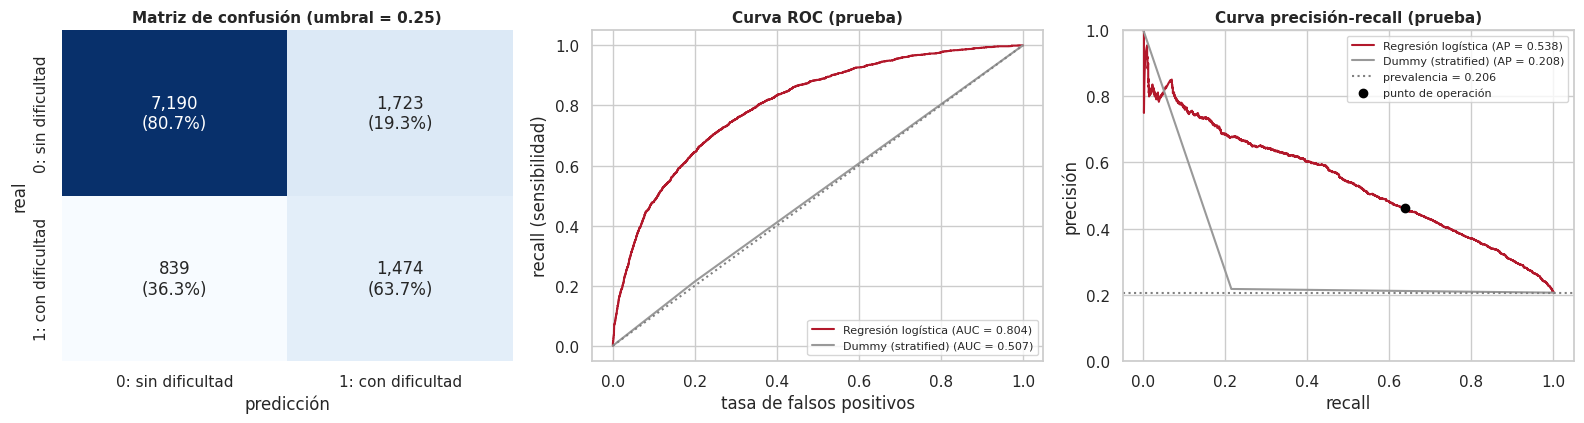

In [6]:
cm = confusion_matrix(y_te, modelos_pred["Regresión logística"])
vn, fp, fn, vp = cm.ravel()
print(f"VP = {vp:,} | FN = {fn:,} | FP = {fp:,} | VN = {vn:,} | especificidad = {vn / (vn + fp):.3f} | "
      f"VPN = {vn / (vn + fn):.3f} | positivos predichos = {vp + fp:,} ({(vp + fp) / len(y_te):.1%} del total)")
fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
etq = ["0: sin dificultad", "1: con dificultad"]
sns.heatmap(cm, annot=np.array([[f"{v:,}\n({v / cm[i].sum():.1%})" for v in fila] for i, fila in enumerate(cm)]),
            fmt="", cmap="Blues", cbar=False, xticklabels=etq, yticklabels=etq, ax=axes[0])
axes[0].set_xlabel("predicción"); axes[0].set_ylabel("real"); axes[0].set_title(f"Matriz de confusión (umbral = {umbral:.2f})")

for nombre, color in [("Regresión logística", "#b2182b"), ("Dummy (stratified)", "#999999")]:
    fpr, tpr, _ = roc_curve(y_te, modelos_prob[nombre])
    axes[1].plot(fpr, tpr, color=color, label=f"{nombre} (AUC = {roc_auc_score(y_te, modelos_prob[nombre]):.3f})")
    pr, rc, _ = precision_recall_curve(y_te, modelos_prob[nombre])
    axes[2].plot(rc, pr, color=color, label=f"{nombre} (AP = {average_precision_score(y_te, modelos_prob[nombre]):.3f})")
axes[1].plot([0, 1], [0, 1], ls=":", color="gray"); axes[1].set_xlabel("tasa de falsos positivos"); axes[1].set_ylabel("recall (sensibilidad)")
axes[1].set_title("Curva ROC (prueba)"); axes[1].legend(fontsize=8, loc="lower right")
axes[2].axhline(y_te.mean(), ls=":", color="gray", label=f"prevalencia = {y_te.mean():.3f}")
i_op = np.argmin(np.abs(precision_recall_curve(y_te, p_lr)[2] - umbral))
axes[2].scatter(recall_score(y_te, p_lr >= umbral), precision_score(y_te, p_lr >= umbral), color="black", zorder=5,
                label="punto de operación")
axes[2].set_xlabel("recall"); axes[2].set_ylabel("precisión"); axes[2].set_title("Curva precisión-recall (prueba)")
axes[2].legend(fontsize=8); axes[2].set_ylim(0, 1)
plt.tight_layout(); plt.show()

#### 3.4.1 Calibración

El modelo está bien calibrado. La curva de calibración sigue de cerca la diagonal, y la probabilidad media predicha (0,207) coincide con la prevalencia observada (0,206). En el decil de mayor riesgo, el modelo predice en promedio 0,652 y la proporción observada es 0,641. Solo en el decil más bajo sobreestima levemente el riesgo, con 0,044 predicho frente a 0,023 observado, una diferencia pequeña en términos absolutos.

El Brier score es de 0,128, frente a 0,164 de predecir siempre la prevalencia, lo que equivale a una mejora relativa, o Brier skill score, del 21,9 %. El histograma ayuda a entender por qué el desempeño es moderado, las dos clases se superponen bastante, aunque los adultos con DCS se concentran en las probabilidades más altas. Esta buena calibración es importante para el uso que se le quiere dar al modelo, porque permite interpretar las probabilidades directamente como un riesgo estimado.

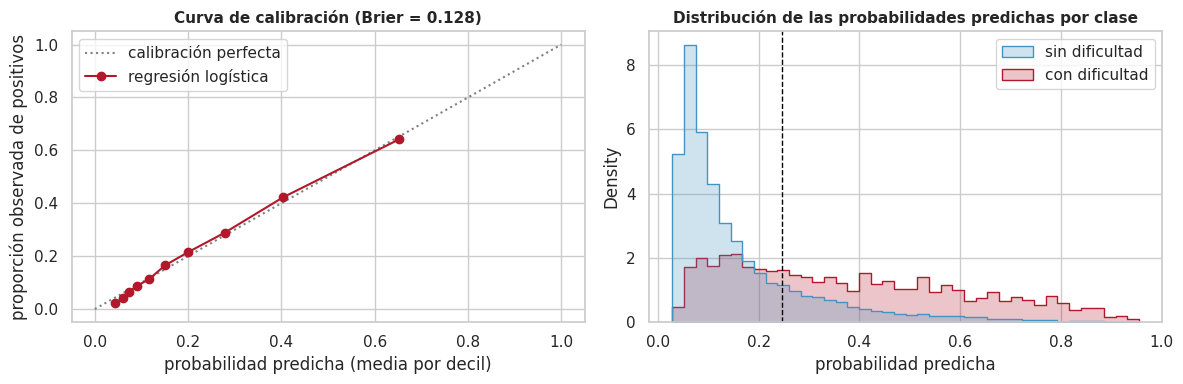

Brier del modelo = 0.1277; Brier de referencia (prevalencia) = 0.1636; Brier skill score = 0.219
Probabilidad media predicha = 0.207 vs. prevalencia observada = 0.206


,0,1,2,3,4,5,6,7,8,9
prob. media predicha,0.0440,0.0590,0.0730,0.0910,0.1160,0.1500,0.2000,0.2780,0.4040,0.6520
proporción observada,0.0230,0.0400,0.0650,0.0880,0.1120,0.1650,0.2150,0.2890,0.4220,0.6410


In [7]:
frac_pos, prob_media = calibration_curve(y_te, p_lr, n_bins=10, strategy="quantile")
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot([0, 1], [0, 1], ls=":", color="gray", label="calibración perfecta")
axes[0].plot(prob_media, frac_pos, "o-", color="#b2182b", label="regresión logística")
axes[0].set_xlabel("probabilidad predicha (media por decil)"); axes[0].set_ylabel("proporción observada de positivos")
axes[0].set_title(f"Curva de calibración (Brier = {brier_score_loss(y_te, p_lr):.3f})"); axes[0].legend()
sns.histplot(x=p_lr, hue=np.where(y_te == 1, "con dificultad", "sin dificultad"), bins=40, stat="density",
             common_norm=False, element="step", ax=axes[1], palette={"con dificultad": "#b2182b", "sin dificultad": "#4393c3"})
axes[1].axvline(umbral, ls="--", color="black", lw=1); axes[1].set_xlabel("probabilidad predicha")
axes[1].set_title("Distribución de las probabilidades predichas por clase")
plt.tight_layout(); plt.show()

brier_ref = brier_score_loss(y_te, np.full_like(p_lr, y_tr.mean()))
print(f"Brier del modelo = {brier_score_loss(y_te, p_lr):.4f}; Brier de referencia (prevalencia) = {brier_ref:.4f}; "
      f"Brier skill score = {1 - brier_score_loss(y_te, p_lr) / brier_ref:.3f}")
print(f"Probabilidad media predicha = {p_lr.mean():.3f} vs. prevalencia observada = {y_te.mean():.3f}")
display(pd.DataFrame({"prob. media predicha": prob_media, "proporción observada": frac_pos}).T.round(3))

#### 3.4.2 Diagnóstico de residuos

La guía pide revisar si los residuos conservan alguna estructura. Como los datos no tienen componente temporal ni espacial, se usa un equivalente, verificar que el residuo medio, entendido como observado menos predicho, sea cercano a cero en los subgrupos relevantes. Un residuo medio que se aleje de cero de forma sistemática en algún subgrupo indicaría información estructural que el modelo no está capturando.

El residuo medio es cercano a cero en casi todos los subgrupos, y sus intervalos incluyen el cero. Por año y trimestre, los residuos van de -0,010 a +0,005, sin ninguna estructura temporal, y el modelo funciona igual en 2022 y en 2023 (ROC-AUC de 0,805 y 0,803). Por sexo, el modelo está calibrado en ambos grupos, con residuos de -0,005 y +0,003, y un ROC-AUC casi igual (0,800 y 0,803).

Aparecen sin embargo dos señales que conviene anotar como información estructural que el modelo todavía no captura. La primera es en los mayores de 75 años, donde el modelo subestima levemente el riesgo, con un residuo de +0,024 en el límite de la significación, y discrimina peor a partir de los 65 años, con un ROC-AUC de 0,74 y 0,73 frente a 0,80-0,82 en menores de 65. En los adultos mayores, la DCS parece depender menos de los factores que el modelo está midiendo. La segunda es en quienes tienen antecedente de ACV, donde el ROC-AUC cae a 0,707 dentro de ese grupo, algo coherente con la interacción entre ACV y edad detectada en el EDA (sección 2.3.4), que un modelo aditivo simplemente no puede representar.

Ambas señales apuntan en la misma dirección, los modelos de las siguientes entregas deberían incluir interacciones, o usar métodos que las aprendan por sí solos, como árboles o boosting.

In [8]:
diag = test.assign(p=p_lr, residuo=y_te - p_lr, grupo_edad=pd.cut(test["edad"], [17, 34, 49, 64, 74, 85]))
filas = []
for var in ["anio", "trimestre", "sexo", "grupo_edad", "acv", "frecuencia_depresion"]:
    for nivel, g in diag.groupby(var, observed=True):
        ic = 1.96 * g["residuo"].std() / np.sqrt(len(g))
        auc = roc_auc_score(g[OBJETIVO], g["p"]) if g[OBJETIVO].nunique() > 1 else np.nan
        filas.append([var, str(nivel), len(g), g[OBJETIVO].mean(), g["p"].mean(), g["residuo"].mean(), ic, auc,
                      average_precision_score(g[OBJETIVO], g["p"])])
res_sub = pd.DataFrame(filas, columns=["variable", "nivel", "n", "observado", "predicho", "residuo medio", "± IC95",
                                       "ROC-AUC", "PR-AUC"])
display(res_sub.style.hide(axis="index").format({"observado": "{:.3f}", "predicho": "{:.3f}", "residuo medio": "{:+.3f}",
                                                 "± IC95": "{:.3f}", "ROC-AUC": "{:.3f}", "PR-AUC": "{:.3f}"})
        .background_gradient(subset=["residuo medio"], cmap="RdBu", vmin=-0.05, vmax=0.05))

variable,nivel,n,observado,predicho,residuo medio,± IC95,ROC-AUC,PR-AUC
anio,2022,5431,0.204,0.205,-0.001,0.009,0.805,0.535
anio,2023,5795,0.208,0.208,-0.000,0.009,0.803,0.542
trimestre,1,2757,0.209,0.204,+0.005,0.013,0.807,0.543
trimestre,2,2710,0.205,0.204,+0.001,0.014,0.797,0.534
trimestre,3,2898,0.198,0.208,-0.010,0.013,0.800,0.537
trimestre,4,2861,0.211,0.210,+0.001,0.013,0.810,0.543
sexo,Hombre,5104,0.180,0.184,-0.005,0.009,0.800,0.495
sexo,Mujer,6121,0.228,0.225,+0.003,0.009,0.803,0.565
grupo_edad,"(17, 34]",2307,0.174,0.182,-0.007,0.014,0.800,0.506
grupo_edad,"(34, 49]",2528,0.136,0.149,-0.013,0.012,0.817,0.485


### 3.5 Curva de aprendizaje

La curva de aprendizaje muestra dos cosas, que el tamaño de la muestra es más que suficiente y que no hay sobreajuste. Con solo 1.800 adultos, la brecha entre entrenamiento y validación es de 0,046, y con los 35.900 de cada partición de entrenamiento completa se reduce a 0,002. La PR-AUC de validación se estabiliza en torno a 0,519 desde unos 16.000 adultos, así que añadir más datos del mismo tipo casi no mejoraría el modelo.

Las dos curvas convergen en un valor moderado, y ese es justamente el patrón de un modelo limitado por sesgo y no por varianza, la regresión logística aditiva ya extrajo todo lo que puede de estas variables. Para mejorar quedan dos caminos, modelos más flexibles que capturen interacciones y no linealidades, o nuevas variables, por ejemplo sueño, actividad física o ansiedad. Esto es justamente lo que justifica la siguiente etapa del proyecto.

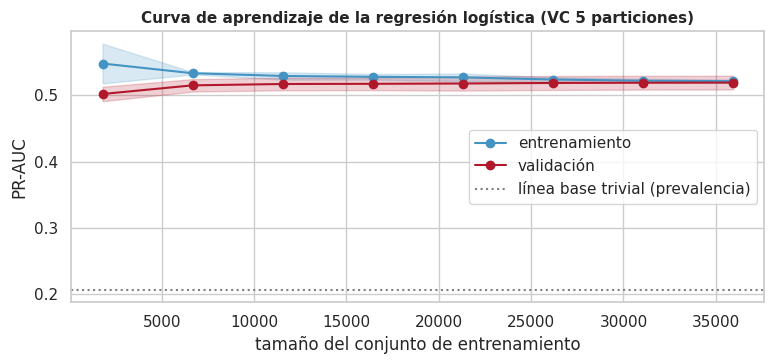

n entrenamiento,PR-AUC entr.,PR-AUC val.,brecha
1796,0.5480,0.5020,0.0460
6671,0.5333,0.5151,0.0183
11546,0.5292,0.5171,0.0121
16421,0.5279,0.5174,0.0106
21296,0.5271,0.5178,0.0093
26171,0.5239,0.5187,0.0052
31046,0.5220,0.5190,0.0029
35922,0.5214,0.5192,0.0021


In [9]:
tamanos, sc_tr, sc_val = learning_curve(mejor, X_tr, y_tr, cv=cv, scoring="average_precision",
                                        train_sizes=np.linspace(0.05, 1.0, 8), n_jobs=-1, shuffle=True, random_state=SEED)
fig, ax = plt.subplots(figsize=(8, 3.8))
for sc, etiqueta, color in [(sc_tr, "entrenamiento", "#4393c3"), (sc_val, "validación", "#b2182b")]:
    ax.plot(tamanos, sc.mean(axis=1), "o-", color=color, label=etiqueta)
    ax.fill_between(tamanos, sc.mean(axis=1) - sc.std(axis=1), sc.mean(axis=1) + sc.std(axis=1), alpha=0.2, color=color)
ax.axhline(y_tr.mean(), ls=":", color="gray", label="línea base trivial (prevalencia)")
ax.set_xlabel("tamaño del conjunto de entrenamiento"); ax.set_ylabel("PR-AUC"); ax.legend()
ax.set_title("Curva de aprendizaje de la regresión logística (VC 5 particiones)")
plt.tight_layout(); plt.show()
display(pd.DataFrame({"n entrenamiento": tamanos, "PR-AUC entr.": sc_tr.mean(axis=1), "PR-AUC val.": sc_val.mean(axis=1),
                      "brecha": sc_tr.mean(axis=1) - sc_val.mean(axis=1)}).style.hide(axis="index").format(precision=4))

### 3.6 Interpretación de los coeficientes

Los coeficientes de la regresión logística se expresan como odds ratios. Un OR de 2 indica que las odds de reportar DCS se duplican respecto a la categoría de referencia, manteniendo constantes las demás variables. Para obtener intervalos de confianza se reajusta el mismo modelo sin penalización con `statsmodels` sobre la matriz preprocesada del entrenamiento. Con la regularización elegida, ambos conjuntos de coeficientes prácticamente coinciden, como se verifica más abajo.

Los coeficientes penalizados y no penalizados son prácticamente idénticos, con una correlación de 0,998, así que los intervalos de `statsmodels` son válidos para el modelo elegido. Todos los OR que siguen están ajustados por las demás variables.

Los síntomas depresivos son el factor más fuerte, con un gradiente dosis-respuesta muy nítido. Frente a quien nunca se siente deprimido, las odds de DCS son 1,9 veces mayores con síntomas pocas veces al año, 2,9 veces con síntomas mensuales, 3,6 con semanales y 4,9 con diarios. El diagnóstico de depresión añade además un OR de 2,2, independiente de los síntomas actuales.

Las pérdidas sensoriales también pesan bastante. La dificultad auditiva tiene un OR de 2,4 con alguna dificultad y 2,6 con mucha, y la visual de 2,1 y 2,5. Esto va en línea con la Comisión Lancet, que considera la pérdida auditiva uno de los factores modificables de mayor peso.

El ACV, que es la exposición de interés de este proyecto, queda con un OR ajustado de 1,69 [1,50-1,90]. Es menor que el OR crudo (3,36) y que el ajustado solo por edad (2,52), porque parte de su asociación se comparte con la depresión, las pérdidas sensoriales y los factores vasculares. Aun así sigue siendo un factor independiente y significativo.

Los factores vasculares y de estilo de vida aumentan el riesgo de forma más modesta, con colesterol alto (1,28), tabaquismo actual (1,19) y pasado (1,17) y diabetes (1,17). La hipertensión, en cambio, deja de ser significativa al ajustar (OR 1,03; IC 0,97-1,09), su asociación cruda en el EDA se explicaba en realidad por la edad y los otros factores cardiometabólicos.

La escolaridad funciona como un factor protector con gradiente. Frente a no terminar la secundaria, las odds son 0,84 veces con secundaria, 0,78 con estudios técnicos o universitarios incompletos, 0,62 con pregrado y 0,53 con posgrado, algo coherente con la hipótesis de la reserva cognitiva.

El IMC, la mayoría de las categorías de raza y etnia, y el sexo no muestran un efecto relevante tras el ajuste (el OR para mujeres es de 1,09, pequeño). Después de corregir por comparaciones múltiples con Holm, la categoría de personas negras no hispanas deja de ser significativa.

Para la edad, los splines reproducen la forma en U ya vista en el EDA. La curva de dependencia parcial, es decir la probabilidad media predicha al fijar la edad y dejar las demás variables como están, va de 0,245 a los 18 años, baja hasta un mínimo de 0,168 a los 51 y sube de nuevo a 0,361 a los 85. En las edades avanzadas queda por debajo de la prevalencia observada, y eso es justamente lo esperado, porque la curva aísla el efecto propio de la edad, mientras que la prevalencia observada en los mayores también incluye su mayor carga de pérdida auditiva, ACV y otros factores, que el modelo ya les atribuye a esas otras variables.

Vale la pena una advertencia. Estas son asociaciones en datos transversales, no efectos causales. La relación entre depresión y DCS probablemente es bidireccional, y parte de ella puede ser simple superposición de síntomas, como ya se discutió en la sección 2.5.

In [10]:
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests

pre_fit = mejor.named_steps["pre"]
nombres = [n.split("__", 1)[1] for n in pre_fit.get_feature_names_out()]
Xm = pd.DataFrame(pre_fit.transform(X_tr), columns=nombres)
logit = sm.Logit(y_tr, sm.add_constant(Xm)).fit(disp=0)
coef_sk = pd.Series(mejor.named_steps["lr"].coef_[0], index=nombres)
print(f"Correlación entre coeficientes penalizados (sklearn) y no penalizados (statsmodels): "
      f"{np.corrcoef(coef_sk, logit.params[nombres])[0, 1]:.4f}")

ors = pd.DataFrame({"OR": np.exp(logit.params), "IC95% inf": np.exp(logit.conf_int()[0]),
                    "IC95% sup": np.exp(logit.conf_int()[1]), "p": logit.pvalues}).drop(index="const")
ors = ors[~ors.index.str.startswith(("edad_sp", "missingindicator"))]
ors["p (Holm)"] = multipletests(ors["p"], method="holm")[1]
display(ors.sort_values("OR", ascending=False).style.format({"OR": "{:.2f}", "IC95% inf": "{:.2f}", "IC95% sup": "{:.2f}",
                                                             "p": "{:.1e}", "p (Holm)": "{:.1e}"})
        .background_gradient(subset=["OR"], cmap="RdBu_r", vmin=0.3, vmax=3.0))

Correlación entre coeficientes penalizados (sklearn) y no penalizados (statsmodels): 0.9977


,OR,IC95% inf,IC95% sup,p,p (Holm)
frecuencia_depresion_Diaria,4.93,4.37,5.55,8.5e-150,2.2e-148
frecuencia_depresion_Semanal,3.61,3.26,4.01,5.7e-130,1.4e-128
frecuencia_depresion_Mensual,2.94,2.67,3.23,1.8e-109,3.9e-108
dificultad_auditiva_Mucha o no puede,2.61,2.20,3.10,7.4e-28,1.5e-26
dificultad_visual_Mucha o no puede,2.47,2.07,2.95,6.0e-24,1.1e-22
dificultad_auditiva_Alguna,2.43,2.28,2.59,4.1e-164,1.1e-162
depresion_dx_Sí,2.20,2.05,2.35,1.3e-110,3.0e-109
dificultad_visual_Alguna,2.10,1.98,2.23,1.4e-125,3.3e-124
frecuencia_depresion_Pocas veces al año,1.91,1.79,2.03,2.5e-86,5.2e-85
acv_Sí,1.69,1.50,1.90,1.6e-17,2.5e-16


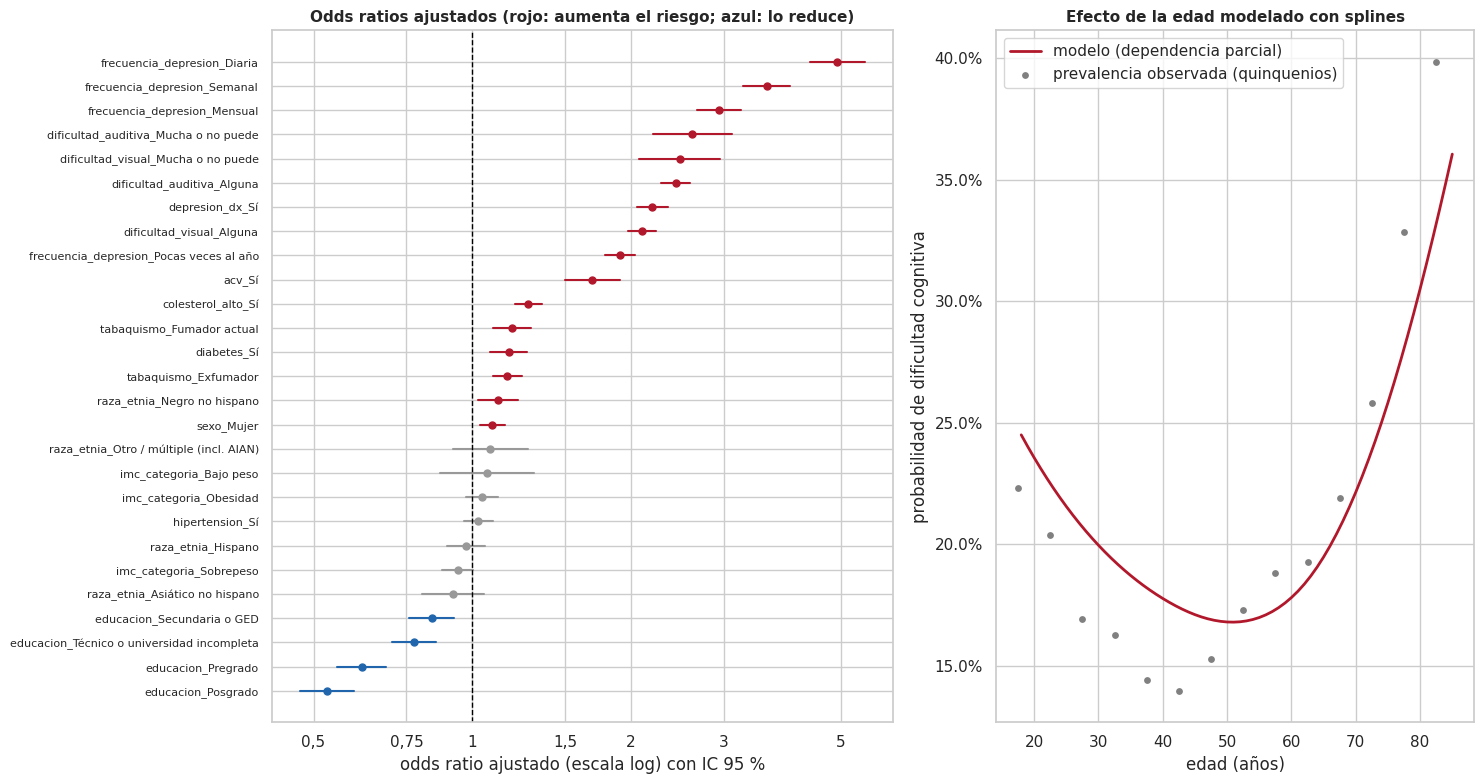

Probabilidad media predicha: 0.245 a los 18 años; mínimo 0.168 a los 51 años; 0.361 a los 85 años


In [11]:
orden = ors.sort_values("OR")
fig, axes = plt.subplots(1, 2, figsize=(15, 8), gridspec_kw={"width_ratios": [1.3, 1]})
colores = np.where(orden["IC95% inf"] > 1, "#b2182b", np.where(orden["IC95% sup"] < 1, "#2166ac", "#999999"))
for i, (nombre_v, fila) in enumerate(orden.iterrows()):
    axes[0].plot([fila["IC95% inf"], fila["IC95% sup"]], [i, i], color=colores[i], lw=1.5)
    axes[0].scatter(fila["OR"], i, color=colores[i], zorder=3, s=25)
axes[0].axvline(1, ls="--", color="black", lw=1); axes[0].set_xscale("log")
axes[0].set_xticks([0.5, 0.75, 1, 1.5, 2, 3, 5], ["0,5", "0,75", "1", "1,5", "2", "3", "5"]); axes[0].minorticks_off()
axes[0].set_yticks(range(len(orden)), orden.index, fontsize=8)
axes[0].set_xlabel("odds ratio ajustado (escala log) con IC 95 %")
axes[0].set_title("Odds ratios ajustados (rojo: aumenta el riesgo; azul: lo reduce)")

# Efecto de la edad (dependencia parcial): probabilidad media predicha al fijar la edad
muestra = X_tr.sample(4000, random_state=SEED)
edades = np.arange(18, 86)
pd_edad = [mejor.predict_proba(muestra.assign(edad=float(e)))[:, 1].mean() for e in edades]
axes[1].plot(edades, pd_edad, color="#b2182b", lw=2, label="modelo (dependencia parcial)")
obs = train.groupby(pd.cut(train["edad"], range(15, 90, 5)), observed=True)[OBJETIVO].mean()
axes[1].scatter([i.mid for i in obs.index], obs.values, color="gray", s=15, label="prevalencia observada (quinquenios)")
axes[1].yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1)); axes[1].legend()
axes[1].set_xlabel("edad (años)"); axes[1].set_ylabel("probabilidad de dificultad cognitiva")
axes[1].set_title("Efecto de la edad modelado con splines")
plt.tight_layout(); plt.show()
print(f"Probabilidad media predicha: {pd_edad[0]:.3f} a los 18 años; mínimo {min(pd_edad):.3f} a los "
      f"{edades[int(np.argmin(pd_edad))]} años; {pd_edad[-1]:.3f} a los 85 años")

### 3.7 Verificación crítica del desempeño

El ROC-AUC de 0,804 entra justo en el borde inferior de la zona que la guía señala para verificar, entre 80 % y 90 %, así que se revisó cada uno de los puntos que pide la nota crítica.

Primero, que no haya fuga, la única variable con desempeño sospechoso, con un AUC univariado de 0,929, ya se había descartado, y sin esa exclusión el modelo habría superado artificialmente el umbral de 0,90. Segundo, que la mejora sobre la línea base sea real, la PR-AUC es 2,6 veces la del modelo trivial, y el accuracy, que en este caso favorecería al modelo trivial, se descartó como métrica de decisión. Tercero, que la validación sea adecuada, no hay estructura temporal ni espacial que infle el desempeño, como confirman los residuos por año y trimestre. Y cuarto, que el problema no sea trivial, una PR-AUC de 0,54 y un F1 de 0,54 dejan todavía un margen amplio de mejora.

El modelo base cumple entonces su función de referencia inicial. El problema resulta aprendible, con una señal real por encima del azar, pero todavía lejos de estar resuelto. El modelo entrenado se guarda en `models/` para compararlo con los modelos de las siguientes entregas.

In [12]:
roc_test, ap_test = roc_auc_score(y_te, p_lr), average_precision_score(y_te, p_lr)
nota = pd.DataFrame([
    ("¿ROC-AUC o PR-AUC ≥ 0,80–0,90?", f"ROC-AUC = {roc_test:.3f}; PR-AUC = {ap_test:.3f}",
     "ROC-AUC en el borde inferior de la zona de alerta; se aplican todas las verificaciones"),
    ("Fuga de datos", "Auditoría 2.5: 3 variables descartadas; AUC univariados ≤ 0,684",
     "Sin fuga en las predictoras finales"),
    ("Comparación con la línea base trivial", f"PR-AUC {ap_test:.3f} vs. {y_te.mean():.3f}; F1 vs. 0 del dummy mayoritario",
     "Mejora real y significativa (IC bootstrap sin superposición)"),
    ("Accuracy engañoso por desbalance", f"Dummy mayoritario: accuracy = {accuracy_score(y_te, modelos_pred['Dummy (prior)']):.3f}",
     "Accuracy descartado como métrica de decisión"),
    ("Estructura temporal/espacial", "Sin coordenadas; año y trimestre sin deriva ni residuos estructurados",
     "La validación aleatoria estratificada es adecuada"),
    ("Sobreajuste", "Brecha entrenamiento–validación < 0,01 en PR-AUC",
     "Sin sobreajuste; el modelo está limitado por sesgo, no por varianza"),
    ("¿Problema trivial para el curso?", "PR-AUC ≈ 0,54: lejos de 1",
     "No: hay amplio margen de mejora para modelos más complejos"),
], columns=["verificación", "resultado", "conclusión"])
display(nota.style.hide(axis="index").set_properties(**{"text-align": "left"}))

DIR_MOD = RAIZ / "models"; DIR_MOD.mkdir(exist_ok=True)
joblib.dump({"modelo": mejor, "umbral": umbral, "seed": SEED}, DIR_MOD / "modelo_base_logistica.joblib")
print(f"Modelo guardado en {DIR_MOD / 'modelo_base_logistica.joblib'}")

verificación,resultado,conclusión
"¿ROC-AUC o PR-AUC ≥ 0,80–0,90?",ROC-AUC = 0.804; PR-AUC = 0.538,ROC-AUC en el borde inferior de la zona de alerta; se aplican todas las verificaciones
Fuga de datos,"Auditoría 2.5: 3 variables descartadas; AUC univariados ≤ 0,684",Sin fuga en las predictoras finales
Comparación con la línea base trivial,PR-AUC 0.538 vs. 0.206; F1 vs. 0 del dummy mayoritario,Mejora real y significativa (IC bootstrap sin superposición)
Accuracy engañoso por desbalance,Dummy mayoritario: accuracy = 0.794,Accuracy descartado como métrica de decisión
Estructura temporal/espacial,Sin coordenadas; año y trimestre sin deriva ni residuos estructurados,La validación aleatoria estratificada es adecuada
Sobreajuste,"Brecha entrenamiento–validación < 0,01 en PR-AUC","Sin sobreajuste; el modelo está limitado por sesgo, no por varianza"
¿Problema trivial para el curso?,"PR-AUC ≈ 0,54: lejos de 1",No: hay amplio margen de mejora para modelos más complejos


Modelo guardado en /home/claude/work/proyecto_nhis_cognicion/models/modelo_base_logistica.joblib
